In [ ]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 6.7 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import torch.nn as nn
class Autoencoder(nn.Module):
    def __init__(self, in_dim=25, bottleneck_dim=3, hidden_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), int(hidden_dim)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim)),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim)),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, int(hidden_dim/2)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/2)),
            nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)),
            nn.ReLU(),
            nn.LayerNorm(int(hidden_dim/4)),
            nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), in_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)

In [5]:
def infer_cell_map(latent_image, model):
    min_vals = torch.tensor([-69.761505, -75.65188,  -77.16103], device=latent_image.device)
    range_vals = torch.tensor([88.969406, 65.244896, 67.13518], device=latent_image.device) - min_vals
    H, W = latent_image.shape[1], latent_image.shape[2]
    latent_image = latent_image.to("cuda")

    range_vals = range_vals.to("cuda")
    min_vals = min_vals.to("cuda")

    flat_img = latent_image.permute(1, 2, 0).reshape(-1, 3)
    white_mask = (flat_img == 1.0).all(dim=1)
    infer_input_rgb = flat_img[~white_mask]
    pred = torch.zeros(flat_img.shape[0], dtype=torch.long, device="cuda")
    if infer_input_rgb.shape[0] > 0:
        z_recovered = infer_input_rgb * range_vals + min_vals
        logits = model.decoder(z_recovered)
        pred[~white_mask] = torch.argmax(logits, dim=1) + 1

    pred = pred.reshape(1, H, W)
    return pred


In [6]:
def load_and_recover_z3d_png(path):
    """
    Load a PNG image as RGB, interpret it as normalized z_3d embedding encoded as uint8 [0–255],
    and recover the original z_3d float values via inverse scaling.
    """
    # 1. Load RGB image as uint8 tensor
    img = Image.open(path).convert("RGB")
    arr = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes()))
    rgb = arr.view(img.size[1], img.size[0], 3).permute(2, 0, 1).clone()  # [3, H, W], uint8
    mask = (rgb > 220).all(dim=0)
    rgb[:, mask] = 255
    rgb_float = rgb.float() / 255.0  # [3, H, W], float32
    non_white_pixels = ((rgb_float != 1).any(dim=0)).sum().item()
    print(f"count for non white: {non_white_pixels}")

    return rgb_float

In [7]:
import torch
from scipy.interpolate import make_interp_spline

yticklabels = [
    "1: B",
    "2: CD4+ T cell",
    "3: CD57+ Enterocyte",
    "4: CD66+ Enterocyte",
    "5: CD7+ Immune",
    "6: CD8+ T",
    "7: Cycling TA",
    "8: DC",
    "9: Endothelial",
    "10: Enterocyte",
    "11: Goblet",
    "12: ICC",
    "13: Lymphatic",
    "14: M1 Macrophage",
    "15: M2 Macrophage",
    "16: MUC1+ Enterocyte",
    "17: NK",
    "18: Nerve",
    "19: Neuroendocrine",
    "20: Neutrophil",
    "21: Paneth",
    "22: Plasma",
    "23: Smooth muscle",
    "24: Stroma",
    "25: TA"
]

cell_type_names = {
    1:  "B", 2:  "CD4+ T", 3:  "CD57+ Ent", 4:  "CD66+ Ent", 5:  "CD7+ Imm",
    6:  "CD8+ T", 7:  "Cycling TA", 8:  "DC", 9:  "Endothelial", 10: "Enterocyte",
    11: "Goblet", 12: "ICC", 13: "Lymphatic", 14: "M1 Mac", 15: "M2 Mac",
    16: "MUC1+ Ent", 17: "NK", 18: "Nerve", 19: "Neuroendocrine", 20: "Neutrophil",
    21: "Paneth", 22: "Plasma", 23: "Smooth muscle", 24: "Stroma", 25: "TA"
}
def rgb_centroid_distance_score(map_true, map_gen, type_true, type_gen, visualize=True, penalty_value=30.0):
    """
    Compute centroid distance for each cell type in RGB space.

    Args:
        map_true: torch.Tensor [3, H, W] - RGB map of true image
        map_gen: torch.Tensor [3, H, W] - RGB map of generated image
        type_true: torch.Tensor [1, H, W] - cell type map of true image
        type_gen: torch.Tensor [1, H, W] - cell type map of generated image
        visualize: bool - whether to plot centroids
        penalty_value: float - penalty for missing types

    Returns:
        score: float - average similarity score
    """
    if map_true.shape[0] == 3:
        map_true = map_true.permute(1, 2, 0).cpu().numpy()
    if map_gen.shape[0] == 3:
        map_gen = map_gen.permute(1, 2, 0).cpu().numpy()

    type_true = type_true.squeeze().cpu().numpy()
    type_gen = type_gen.squeeze().cpu().numpy()

    centroids_true = {}
    centroids_gen = {}
    all_types = set(np.unique(type_true)).union(np.unique(type_gen))
    all_types.discard(0)  # ignore background

    for t in all_types:
        coords_true = np.argwhere(type_true == t)
        coords_gen = np.argwhere(type_gen == t)

        if len(coords_true) > 0:
            rgbs_true = map_true[coords_true[:, 0], coords_true[:, 1]]
            centroids_true[t] = rgbs_true.mean(axis=0)

        if len(coords_gen) > 0:
            rgbs_gen = map_gen[coords_gen[:, 0], coords_gen[:, 1]]
            centroids_gen[t] = rgbs_gen.mean(axis=0)

    distances = []
    for t in sorted(all_types):
        if t in centroids_true and t in centroids_gen:
            d = np.linalg.norm(centroids_true[t] - centroids_gen[t])
        else:
            d = penalty_value
        distances.append(d)

    if visualize:
        fig = plt.figure(figsize=(13, 8))
        ax = fig.add_subplot(111, projection='3d')

        for t in sorted(all_types):
            color = centroids_true.get(t, centroids_gen.get(t, [0.5, 0.5, 0.5]))
            if t in centroids_true:
                ax.scatter(*centroids_true[t], marker='o', color=color, s=80, label=cell_type_names[t])
            if t in centroids_gen:
                ax.scatter(*centroids_gen[t], marker='^', color=color, s=80, label=cell_type_names[t])
            if t in centroids_true and t in centroids_gen:
                ax.plot(
                    [centroids_true[t][0], centroids_gen[t][0]],
                    [centroids_true[t][1], centroids_gen[t][1]],
                    [centroids_true[t][2], centroids_gen[t][2]],
                    'k--', alpha=0.4
                )

        ax.set_xlabel('R')
        ax.set_ylabel('G')
        ax.set_zlabel('B')
        ax.set_title("RGB Centroid Distance per Cell Type (3D)")
        ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=9, ncol=2)
        plt.tight_layout()
        plt.show()

    avg_dist = np.mean(distances)
    return avg_dist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.spatial.distance import jensenshannon
from scipy.optimize import linear_sum_assignment


def catplot2(df, hue, exp='Exp', X='X', Y='Y', invert_y=False, size=3, legend=True, palette="bright", figsize=10,
             style='white', exps=None, axis='on', scatter_kws={}):
    '''
    Plots cells in tissue section color coded by either cell type or node allocation.
    df:  dataframe with cell information
    size:  size of point to plot for each cell.
    hue:  color by "Clusterid" or "Node" respectively.
    legend:  to include legend in plot.
    '''
    scatter_kws_ = {'s': size, 'alpha': 1}
    scatter_kws_.update(scatter_kws)

    figures = []
    df = df.rename(columns=lambda x: str(x))

    df[hue] = df[hue].astype("category")
    if invert_y:
        y_orig = df[Y].values.copy()
        df[Y] *= -1

    style = {'axes.facecolor': style}
    sns.set_style(style)
    if exps == None:
        exps = list(df[exp].unique())  # display all experiments
    elif type(exps) != list:
        exps = [exps]

    for name in exps:
        data = df[df[exp] == name]

        #print(name)
        f = sns.lmplot(x=X, y=Y, data=data, hue=hue,
                       legend=legend, fit_reg=False, markers='.', height=figsize, palette=palette, scatter=True,
                       scatter_kws=scatter_kws_)
        f.ax.set_aspect('equal')
        if axis == 'off':
            sns.despine(top=True, right=True, left=True, bottom=True)
            f = f.set(xticks=[], yticks=[]).set_xlabels('').set_ylabels('')

        plt.title(name)

        plt.show()
        figures += [f]
    if invert_y:
        df[Y] = y_orig

    return figures
from matplotlib.colors import ListedColormap

import matplotlib.pyplot as plt
import numpy as np

def plot_cluster_map(cluster_labels, coords, title, H, W, palette=None, size=3, legend=False):
    """
    用 scatter 方式画出聚类坐标点，颜色由 cluster 决定。

    Args:
        cluster_labels: (N,) array，每个点的聚类编号
        coords: (N, 2) array，格式为 (y, x) 或 (row, col)
        title: 图标题
        H, W: 图像高度宽度（用于设定显示范围）
        palette: list of RGB tuples（推荐与 catplot2 用的一致）
        size: 每个点的大小
        legend: 是否显示图例
    """
    coords = np.array(coords)
    x = coords[:, 0]
    y = coords[:, 1]
    labels = cluster_labels

    plt.figure(figsize=(10, 10))
    ax = plt.gca()

    unique_labels = np.unique(labels)

    for label in unique_labels:
        mask = labels == label
        color = palette[label] if palette else None
        ax.scatter(x[mask], y[mask], s=size, c=color, label=f"Cluster {label}", marker='s', linewidth=0)

    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')
    plt.title(title)

    if legend:
        ax.legend(loc='upper right', fontsize=6, frameon=False)

    plt.tight_layout()
    plt.show()


import torch

def compute_ratio(arr, num_types=25):
    if num_types == 25:
        arr = arr.astype(int) - 1  # 转为 0-based
    else:
        arr = arr.astype(int)
    counts = np.bincount(arr, minlength=num_types)
    ratio = counts / counts.sum()
    return ratio
def compute_hist(features, coords, k=20, num_types=25):
    if num_types != 25:
        features = features.astype(int) + 1
    nbrs = NearestNeighbors(n_neighbors=min(k, len(coords))).fit(coords)
    _, indices = nbrs.kneighbors(coords)

    hist = np.zeros((len(coords), num_types), dtype=np.float32)

    for i, neighbors in enumerate(indices):
        for nid in neighbors:
            t = int(features[nid])
            if 1 <= t <= num_types:
                hist[i, t - 1] += 1

    # 构建 DataFrame
    if num_types == 25:
        col_names = [
        "B", "CD4+ T", "CD57+ Ent", "CD66+ Ent", "CD7+ Imm",
        "CD8+ T", "Cycling TA", "DC", "Endothelial", "Enterocyte",
        "Goblet", "ICC", "Lymphatic", "M1 Mac", "M2 Mac",
        "MUC1+ Ent", "NK", "Nerve", "Neuroendocrine", "Neutrophil",
        "Paneth", "Plasma", "Smooth muscle", "Stroma", "TA"
        ]
        df = pd.DataFrame(hist, columns=col_names)
    else:
        df = pd.DataFrame(hist)

    # 添加 cell 坐标与 cell type
    df["y"] = coords[:, 0]
    df["x"] = coords[:, 1]
    df["cell_type"] = features

    # 保存 CSV
    df.to_csv("1.csv", index=False)
    return hist

old_order = [
    "B", "CD4+ T", "CD57+ Ent", "CD66+ Ent", "CD7+ Imm",
    "CD8+ T", "Cycling TA", "DC", "Endothelial", "Enterocyte",
    "Goblet", "ICC", "Lymphatic", "M1 Mac", "M2 Mac",
    "MUC1+ Ent", "NK", "Nerve", "Neuroendocrine", "Neutrophil",
    "Paneth", "Plasma", "Smooth muscle", "Stroma", "TA"
]

# 新顺序（目标顺序）
new_order = [
    'Goblet', 'CD66+ Enterocyte', 'Enterocyte', 'Plasma', 'Endothelial',
    'Stroma', 'ICC', 'Smooth muscle', 'Cycling TA', 'M2 Macrophage',
    'Nerve', 'CD4+ T cell', 'Lymphatic', 'TA', 'MUC1+ Enterocyte', 'B',
    'DC', 'CD8+ T', 'NK', 'Neutrophil', 'CD57+ Enterocyte', 'CD7+ Immune',
    'Neuroendocrine', 'M1 Macrophage'
]

# 创建新名到旧名的手动映射（处理名字不同）
name_map = {
    'Goblet': 'Goblet',
    'CD66+ Enterocyte': 'CD66+ Ent',
    'Enterocyte': 'Enterocyte',
    'Plasma': 'Plasma',
    'Endothelial': 'Endothelial',
    'Stroma': 'Stroma',
    'ICC': 'ICC',
    'Smooth muscle': 'Smooth muscle',
    'Cycling TA': 'Cycling TA',
    'M2 Macrophage': 'M2 Mac',
    'Nerve': 'Nerve',
    'CD4+ T cell': 'CD4+ T',
    'Lymphatic': 'Lymphatic',
    'TA': 'TA',
    'MUC1+ Enterocyte': 'MUC1+ Ent',
    'B': 'B',
    'DC': 'DC',
    'CD8+ T': 'CD8+ T',
    'NK': 'NK',
    'Neutrophil': 'Neutrophil',
    'CD57+ Enterocyte': 'CD57+ Ent',
    'CD7+ Immune': 'CD7+ Imm',
    'Neuroendocrine': 'Neuroendocrine',
    'M1 Macrophage': 'M1 Mac',
}

def compute_cluster_celltype_composition(cluster_labels, cell_types, n_clusters=5, n_types=34):
    #print("cluster_labels.shape",cluster_labels.shape)
    #print("cell_types.shape",cell_types.shape)
    #print(np.unique(cluster_labels))
    #print(np.unique(cell_types))
    comp = np.zeros((n_clusters, n_types), dtype=np.float32)
    for i in range(len(cluster_labels)):
        c = cluster_labels[i]
        t = cell_types[i] - 1
        comp[c, t] += 1
    #comp /= (comp.sum(axis=0, keepdims=True) + 1e-8)
    return comp

def raw_proportion_heatmap(comp, title, cell_types_fixed_order, row_order=None):
    if row_order is not None:
        comp = comp[row_order]
        comp = comp / (comp.sum(axis=1, keepdims=True) + 1e-8)
    df = pd.DataFrame(comp, columns=cell_types_fixed_order)
    sns.heatmap(df, vmin=0, vmax=1, cmap='Blues', xticklabels=cell_types_fixed_order, yticklabels=[f"C{i}" for i in range(comp.shape[0])])
    plt.title(title + " (Proportion)")
    plt.xlabel("Cell Type")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def compare_cluster_feature_centroids(features1, labels1, features2, labels2, n_clusters, metric='euclidean'):
    dim1 = features1.shape[1]
    dim2 = features2.shape[1]

    if dim1 != dim2:
        print(f"[Warn] feature dim mismatch: features1={dim1}, features2={dim2}")

        max_dim = max(dim1, dim2)

        def pad_to(x, d):
            if x.shape[1] == d:
                return x
            pad_width = d - x.shape[1]
            return np.pad(x, ((0, 0), (0, pad_width)), mode='constant')

        features1 = pad_to(features1, max_dim)
        features2 = pad_to(features2, max_dim)

    global_mean1 = features1.mean(axis=0)
    global_mean2 = features2.mean(axis=0)

    centroids1 = []
    centroids2 = []

    for i in range(n_clusters):
        f1 = features1[labels1 == i]
        f2 = features2[labels2 == i]

        c1 = f1.mean(axis=0) if len(f1) > 0 else global_mean1
        c2 = f2.mean(axis=0) if len(f2) > 0 else global_mean2

        centroids1.append(c1)
        centroids2.append(c2)

    centroids1 = np.stack(centroids1)
    centroids2 = np.stack(centroids2)

    cost_matrix = cdist(centroids1, centroids2, metric=metric)

    if np.any(np.isnan(cost_matrix)) or cost_matrix.shape[0] == 0:
        return [0], [0], np.array([[9999.0]]), 9999.0

    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    total_dist = cost_matrix[row_ind, col_ind].sum()
    matched_distances = cost_matrix

    min_dist = matched_distances.min()
    max_dist = matched_distances.max()

    if max_dist > min_dist:
        normalized = (matched_distances - min_dist) / (max_dist - min_dist)
    else:
        normalized = np.zeros_like(matched_distances)

    return row_ind, col_ind, cost_matrix, normalized[row_ind, col_ind].sum()


def log2_fc_heatmap_from_centroids0(niche_clusters, tissue_values, cell_types_fixed_order, k_value, row_order=None):
    tissue_avg = tissue_values#.mean(axis=0, keepdims=True) + 1e-8
    smoothed = niche_clusters + tissue_avg

    smoothed_norm = smoothed / smoothed.sum(axis=1, keepdims=True)
    fc_log = np.log2(smoothed_norm / tissue_avg)
    if row_order is not None:
        fc_log = fc_log[row_order]
    if len(tissue_avg) == 25:
        df = pd.DataFrame(fc_log, columns=cell_types_fixed_order)
    else:
        df = pd.DataFrame(fc_log)
    plt.figure(figsize=(10, 8))
    if len(tissue_avg) == 25:
        sns.clustermap(df, vmin=-3, vmax=3, cmap='bwr',
                xticklabels=cell_types_fixed_order,
                yticklabels=[f"C{i}" for i in range(fc_log.shape[0])])
    else:
        sns.clustermap(df, vmin=-3, vmax=3, cmap='bwr')
    plt.title(f"Log2 FC Heatmap (k={k_value})")
    plt.xlabel("Cell Type")
    plt.ylabel("Cluster Centroid")
    plt.tight_layout()
    plt.show()

def log2_fc_heatmap_from_centroids1(
    niche_clusters, tissue_values, cell_types_fixed_order, k_value, row_order=None
):
    # 避免 tissue_avg 为零
    tissue_avg = tissue_values + 1e-8
    print("tissue", tissue_avg)
    print("cluster",niche_clusters)

    smoothed = niche_clusters + tissue_avg

    # 避免行和为零
    smoothed_norm = smoothed / (smoothed.sum(axis=1, keepdims=True) + 1e-8)

    # log2 fold change
    fc_log = np.log2(smoothed_norm / tissue_avg)

    # 如果需要 reorder
    if row_order is not None:
        fc_log = fc_log[row_order]

    # 创建 DataFrame
    if len(tissue_avg) == 25:
        df = pd.DataFrame(fc_log, columns=cell_types_fixed_order)
    else:
        df = pd.DataFrame(fc_log)

    # 替换 inf、-inf 为 NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # 用 0 填充 NaN
    df.fillna(0, inplace=True)

    # 检查是否还有非法值
    if df.isnull().values.any() or np.isinf(df.values).any():
        print("Warning: DataFrame still contains NaN or inf values!")

    plt.figure(figsize=(10, 8))

    if len(tissue_avg) == 25:
        sns.clustermap(
            df,
            vmin=-3,
            vmax=3,
            cmap='bwr',
            xticklabels=cell_types_fixed_order,
            yticklabels=[f"C{i}" for i in range(fc_log.shape[0])]
        )
    else:
        sns.clustermap(
            df,
            vmin=-3,
            vmax=3,
            cmap='bwr'
        )

    plt.title(f"Log2 FC Heatmap (k={k_value})")
    plt.xlabel("Cell Type")
    plt.ylabel("Cluster Centroid")
    plt.tight_layout()
    plt.show()

def log2_fc_heatmap_from_centroids(niche_clusters, tissue_values, cell_types_fixed_order, k_value, row_order=None):
        tissue_avg = tissue_values  # .mean(axis=0, keepdims=True) + 1e-8
        valid_idx = tissue_avg != 0
        tissue_avg = tissue_avg[valid_idx]
        # print(niche_clusters)
        # print(tissue_avg)
        smoothed = niche_clusters + tissue_avg

        smoothed_norm = smoothed / smoothed.sum(axis=1, keepdims=True)
        fc_log = np.log2(smoothed_norm / tissue_avg)
        if row_order is not None:
            fc_log = fc_log[row_order]
        if len(tissue_avg) == 25:
            df = pd.DataFrame(fc_log, columns=cell_types_fixed_order)
        else:
            df = pd.DataFrame(fc_log)
        plt.figure(figsize=(10, 8))
        if len(tissue_avg) == 25:
            sns.heatmap(df, vmin=-3, vmax=3, cmap='bwr',
                        xticklabels=cell_types_fixed_order,
                        yticklabels=[f"C{i}" for i in range(fc_log.shape[0])])
        else:
            sns.heatmap(df, vmin=-3, vmax=3, cmap='bwr')
        plt.title(f"Log2 FC Heatmap (k={k_value})")
        plt.xlabel("Cell Type")
        plt.ylabel("Cluster Centroid")
        plt.tight_layout()
        plt.show()


def print_composition_summary(comp, title, cell_type_names):
    total_proportion = comp.sum(axis=0) / comp.sum()
    print(f"===== {title} =====")
    print("Total Proportion per Cell Type:")
    for i, name in enumerate(cell_type_names):
        print(f"{name}: {total_proportion[i]:.4f}")
    print("\\nPer-Cluster Proportion:")
    df = pd.DataFrame(comp, columns=cell_type_names)
    print(df.round(3))
    print("\\n")

def neighbor_kmeans_composition_matching_score(true_map, gen_map1, gen_map2, gen_map3,
                                               k=50, n_clusters=5, visualize=True):
    maps = [gen_map1, gen_map2, gen_map3]
    scores = []
    yticklabels = [
        "B", "CD4+ T", "CD57+ Ent", "CD66+ Ent", "CD7+ Imm",
        "CD8+ T", "Cycling TA", "DC", "Endothelial", "Enterocyte",
        "Goblet", "ICC", "Lymphatic", "M1 Mac", "M2 Mac",
        "MUC1+ Ent", "NK", "Nerve", "Neuroendocrine", "Neutrophil",
        "Paneth", "Plasma", "Smooth muscle", "Stroma", "TA"
    ]

    map_true = true_map.squeeze(0)
    H, W = map_true.shape
    coords_true = np.array([(x, y) for y in range(H) for x in range(W)])
    feats_true = map_true.flatten().cpu().numpy()
    mask_true = feats_true != 0
    feats_true = feats_true[mask_true]
    coords_true = coords_true[mask_true]
    hist_true = compute_hist(feats_true, coords_true, k=k)
    km_true = MiniBatchKMeans(n_clusters=n_clusters, random_state=0).fit(hist_true)
    cluster_labels_true = km_true.labels_
    centers = km_true.cluster_centers_
    #print("centers", centers)
    ratio_true = compute_ratio(feats_true)
    #print("ratio_true", ratio_true)
    if visualize:
        plot_cluster_map(cluster_labels_true, coords_true, "True Map Clustered", H, W)
        log2_fc_heatmap_from_centroids1(
            niche_clusters=centers,
            tissue_values=ratio_true,
            cell_types_fixed_order=yticklabels,
            k_value=n_clusters,
            row_order=None
        )

    for i in range(3):
        map_gen = maps[i].squeeze(0)
        coords_gen = np.array([(x, y) for y in range(H) for x in range(W)])
        feats_gen = map_gen.flatten().cpu().numpy()
        mask_gen = feats_gen != 0
        feats_gen = feats_gen[mask_gen]
        coords_gen = coords_gen[mask_gen]
        #print("type_gen1", feats_gen.shape)
        #print("Number of non-zero points:", len(feats_gen))

        hist_gen = compute_hist(feats_gen, coords_gen, k=k)
        ratio_gen = compute_ratio(feats_gen)
        km_gen = MiniBatchKMeans(n_clusters=n_clusters, random_state=0)
        cluster_labels_gen = km_gen.fit_predict(hist_gen)
        centers = km_gen.cluster_centers_
        comp_gen = compute_cluster_celltype_composition(cluster_labels_gen, feats_gen, n_clusters)

        if visualize:
            plot_cluster_map(cluster_labels_gen, coords_gen, f"Gen Map {i + 1} Clustered", H, W)
            df = pd.DataFrame(coords_gen, columns=["X", "Y"])
            df["Clusterid"] = cluster_labels_gen
            df["Exp"] = "1"
            catplot2(df, hue="Clusterid", exp="Exp", X="X", Y="Y", invert_y=True)

        row_order, col_order, cost_matrix, total_dist = compare_cluster_feature_centroids(
            hist_true, cluster_labels_true,
            hist_gen, cluster_labels_gen,
            n_clusters=n_clusters,
            metric='euclidean'
        )

        comp_gen_aligned = comp_gen[col_order]

        if visualize:
            log2_fc_heatmap_from_centroids1(
                niche_clusters=centers,
                tissue_values=ratio_gen,
                cell_types_fixed_order=yticklabels,
                k_value=n_clusters,
                row_order=range(comp_gen_aligned.shape[0])
            )

        scores.append(1/(1+total_dist))

    return scores

def double_neighbor_kmeans_composition_matching_score(true_map, gen_map1, gen_map2, gen_map3,
                                               k=50, n_clusters=5, visualize=True):
    maps = [gen_map1, gen_map2, gen_map3]
    scores = []
    yticklabels = [
        "B", "CD4+ T", "CD57+ Ent", "CD66+ Ent", "CD7+ Imm",
        "CD8+ T", "Cycling TA", "DC", "Endothelial", "Enterocyte",
        "Goblet", "ICC", "Lymphatic", "M1 Mac", "M2 Mac",
        "MUC1+ Ent", "NK", "Nerve", "Neuroendocrine", "Neutrophil",
        "Paneth", "Plasma", "Smooth muscle", "Stroma", "TA"
    ]

    map_true = true_map.squeeze(0)
    H, W = map_true.shape
    coords_true = np.array([(x, y) for y in range(H) for x in range(W)])
    feats_true = map_true.flatten().cpu().numpy()
    mask_true = feats_true != 0
    feats_true = feats_true[mask_true]
    coords_true = coords_true[mask_true]
    hist_true = compute_hist(feats_true, coords_true, k=20)
    km_true = MiniBatchKMeans(n_clusters=n_clusters, random_state=0).fit(hist_true)
    cluster_labels_true = km_true.labels_
    hist_true = compute_hist(cluster_labels_true, coords_true, k=k, num_types=len(np.unique(cluster_labels_true)))
    km_true = MiniBatchKMeans(n_clusters=n_clusters, random_state=0).fit(hist_true)
    cluster_labels_true1 = km_true.labels_
    centers = km_true.cluster_centers_
    #print(np.unique(cluster_labels_true1))
    ratio_true = compute_ratio(cluster_labels_true1, len(np.unique(cluster_labels_true1)))

    if visualize:
        plot_cluster_map(cluster_labels_true, coords_true, "Lower True Map Clustered", H, W)
        plot_cluster_map(cluster_labels_true1, coords_true, "Higher True Map Clustered", H, W)
        log2_fc_heatmap_from_centroids(
            niche_clusters=centers,
            tissue_values=ratio_true,
            cell_types_fixed_order=yticklabels,
            k_value=n_clusters,
            row_order=None
        )

    for i in range(3):
        print(i)
        map_gen = maps[i].squeeze(0)
        coords_gen = np.array([(x, y) for y in range(H) for x in range(W)])
        feats_gen = map_gen.flatten().cpu().numpy()
        mask_gen = feats_gen != 0
        feats_gen = feats_gen[mask_gen]
        coords_gen = coords_gen[mask_gen]
        #print("type_gen1", feats_gen.shape)
        #print("Number of non-zero points:", len(feats_gen))

        hist_gen = compute_hist(feats_gen, coords_gen, k=20)
        km_gen = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels_gen = km_gen.fit_predict(hist_gen)
        hist_gen = compute_hist(cluster_labels_gen, coords_gen, k=k, num_types=len(np.unique(cluster_labels_gen)))
        ratio_gen = compute_ratio(cluster_labels_gen, len(np.unique(cluster_labels_gen)))
        km_gen = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels_gen1 = km_gen.fit_predict(hist_gen)

        centers = km_gen.cluster_centers_
        comp_gen = compute_cluster_celltype_composition(cluster_labels_gen1, cluster_labels_gen, n_clusters, max(np.unique(cluster_labels_gen1)) + 1)

        if visualize:
            plot_cluster_map(cluster_labels_gen, coords_gen, f"Lower Gen Map {i + 1} Clustered", H, W)
            plot_cluster_map(cluster_labels_gen1, coords_gen, f"Higher Gen Map {i + 1} Clustered", H, W)
            df = pd.DataFrame(coords_gen, columns=["X", "Y"])
            df["Clusterid"] = cluster_labels_gen1
            df["Exp"] = "1"
            catplot2(df, hue="Clusterid", exp="Exp", X="X", Y="Y", invert_y=True)
        row_order, col_order, cost_matrix, total_dist = compare_cluster_feature_centroids(
            hist_true, cluster_labels_true1,
            hist_gen, cluster_labels_gen1,
            n_clusters=n_clusters,
            metric='euclidean'
        )

        comp_gen_aligned = comp_gen[col_order]

        if visualize:
            log2_fc_heatmap_from_centroids(
                niche_clusters=centers,
                tissue_values=ratio_gen,
                cell_types_fixed_order=yticklabels,
                k_value=n_clusters,
                row_order=range(comp_gen_aligned.shape[0])
            )

        scores.append(1/(1+total_dist))

    return scores

def cell_density_score_new(true_map, gen_map1, gen_map2, gen_map3,
                             k=20, bin_width=0.1, penalty_value=30.0, visualize=True):
    import numpy as np
    from sklearn.neighbors import NearestNeighbors
    from scipy.stats import entropy
    import matplotlib.pyplot as plt

    def get_coords_and_feats(types):
        H, W = types.shape[1:]
        coords = np.array([(i, j) for i in range(H) for j in range(W)])
        feats = types.squeeze(0).flatten().cpu().numpy()
        mask = feats != 0
        return coords[mask], feats[mask]

    def get_distance_distributions(coords, feats):
        dists_by_type = [None] * 25
        for t in range(1, 25):
            points = coords[feats == t]
            if len(points) < k + 1:
                continue
            nbrs = NearestNeighbors(n_neighbors=k + 1).fit(points)
            dists, _ = nbrs.kneighbors(points)
            mean_dists = dists[:, 1:].mean(axis=1)
            dists_by_type[t] = mean_dists
        return dists_by_type

    maps = [true_map, gen_map1, gen_map2, gen_map3]
    all_dists_by_map = []

    for m in maps:
        coords, feats = get_coords_and_feats(m)
        all_dists_by_map.append(get_distance_distributions(coords, feats))

    # 只收集 gen1/2/3 对 true_map 的所有 cell type 的分数
    num_gen = 3
    score_matrix = [[] for _ in range(num_gen)]  # score_matrix[i]: gen_i 的所有cell type得分

    for t in range(1, 25):
        all_dists = [d[t] for d in all_dists_by_map]
        if any(x is None for x in all_dists):
            for i in range(num_gen):
                score_matrix[i].append(1 / (1 + penalty_value))
            continue

        # Min-max normalize within this cell type
        combined = np.concatenate(all_dists)
        min_v, max_v = combined.min(), combined.max()
        if max_v - min_v < 1e-8:
            for i in range(num_gen):
                score_matrix[i].append(1.0)
            continue

        bin_edges = np.arange(0, 1 + bin_width, bin_width)
        hists = []
        for d in all_dists:
            normed = (d - min_v) / (max_v - min_v)
            binned = np.round(normed / bin_width) * bin_width
            hist, _ = np.histogram(binned, bins=bin_edges)
            hist = hist.astype(np.float32) + 1e-8
            hist /= hist.sum()
            hists.append(hist)

        true_hist = hists[0]
        for i in range(num_gen):
            kl = entropy(true_hist, hists[i + 1])
            score = 1 / (1 + kl)
            score_matrix[i].append(score)

            if visualize:
                plt.figure(figsize=(6, 3))

                # 平滑 True histogram 曲线
                x = bin_edges[:-1]
                y = true_hist
                if len(x) > 3:
                    x_new = np.linspace(x.min(), x.max(), 300)  # 增加插值点
                    spl = make_interp_spline(x, y, k=3)  # B-spline 三次平滑
                    y_smooth = spl(x_new)
                    plt.plot(x_new, y_smooth, label='True')
                else:
                    plt.plot(x, y, label='True')

                # 平滑生成的 histogram 曲线
                y_gen = hists[i + 1]
                if len(x) > 3:
                    spl_gen = make_interp_spline(x, y_gen, k=3)
                    y_gen_smooth = spl_gen(x_new)
                    if i == 0:
                        plt.plot(x_new, y_gen_smooth, label='Held-Out True')
                    elif i == 1:
                        plt.plot(x_new, y_gen_smooth, label='DISCO')
                    elif i == 2:
                        plt.plot(x_new, y_gen_smooth, label='Diffuser')
                else:
                    if i == 0:
                        plt.plot(x, y_gen, label='Held-Out True')
                    elif i == 1:
                        plt.plot(x, y_gen, label='DISCO')
                    elif i == 2:
                        plt.plot(x, y_gen, label='Diffuser')

                plt.title(f"Cell Type {t} Distance Distribution (True vs Gen {i + 1})")
                plt.xlabel("Normalized Relative Distance")
                plt.ylabel("Frequency")
                plt.legend()

                # 移除右边和上边的边框
                ax = plt.gca()
                ax.spines['right'].set_visible(False)
                ax.spines['top'].set_visible(False)

                # 去掉网格线
                plt.grid(False)

                plt.tight_layout()
                plt.savefig(f"{i}.png", bbox_inches='tight', dpi=300)
                plt.show()

    # 对每个 gen，计算所有 cell type 的平均分数
    avg_scores = [np.mean(s) for s in score_matrix]
    return avg_scores


from skimage.metrics import structural_similarity as ssim

import lpips

lpips_loss_fn = lpips.LPIPS(net='vgg').to("cuda")

def spatial_structure_score(true_map, gen_map):
    """
    Compute LPIPS perceptual similarity between two RGB maps.
    Input: [3, H, W], float in [0, 1] (normalized image)
    Returns: float score, lower is more similar
    """
    m1 = torch.as_tensor(true_map).squeeze().to("cuda")
    m2 = torch.as_tensor(gen_map).squeeze().to("cuda")

    if m1.ndim != 3 or m1.shape[0] != 3:
        raise ValueError("Input map must have shape [3, H, W]")

    # Normalize from [0,1] to [-1,1] as required by LPIPS
    m1 = m1 * 2 - 1
    m2 = m2 * 2 - 1

    m1 = m1.unsqueeze(0)  # Add batch dimension: [1, 3, H, W]
    m2 = m2.unsqueeze(0)

    with torch.no_grad():
        score = lpips_loss_fn(m1, m2).item()

    return 1 - score

def cell_type_distribution(true_map, generated_map, show_plot=False, type_color_dict=None):
    type_color_dict = {
        1: [134.9, 124.1, 8.7],
        2: [62.3, 216.0, 132.0],
        3: [130.9, 46.4, 182.5],
        4: [92.8, 63.6, 202.5],
        5: [140.1, 239.7, 189.0],
        6: [200.0, 183.1, 168.9],
        7: [108.3, 16.1, 142.3],
        8: [132.7, 217.1, 223.4],
        9: [170.6, 96.0, 98.0],
        10: [68.4, 101.1, 101.3],
        11: [4.6, 146.9, 145.6],
        12: [177.1, 1.5, 112.2],
        13: [202.6, 136.4, 12.3],
        14: [95.1, 244.3, 209.6],
        15: [32.5, 214.2, 217.8],
        16: [176.2, 78.6, 193.2],
        17: [185.9, 206.0, 77.8],
        18: [212.0, 39.3, 35.0],
        19: [117.1, 190.4, 53.4],
        20: [101.2, 145.2, 246.9],
        21: [13.7, 179.1, 133.2],
        22: [247.4, 125.5, 111.5],
        23: [122.9, 151.0, 150.0],
        24: [118.0, 45.6, 47.7],
        25: [31.1, 114.7, 222.5]
    }
    """
    Compare the global cell type distribution between the true and generated maps,
    using KL divergence. Each bar is colored by cell type RGB; true uses solid bars, generated uses hatched.

    Args:
        true_map: torch.Tensor, shape [1, H, W]
        generated_map: torch.Tensor, shape [1, H, W]
        show_plot: bool
        type_color_dict: dict[int -> list of RGB in 0-255], key=cell type (1~25)

    Returns:
        similarity_score: float
    """
    import numpy as np
    import matplotlib.pyplot as plt

    cell_type_names = [
        "B", "CD4+ T cell", "CD57+ Enterocyte", "CD66+ Enterocyte", "CD7+ Immune",
        "CD8+ T", "Cycling TA", "DC", "Endothelial", "Enterocyte", "Goblet", "ICC",
        "Lymphatic", "M1 Macrophage", "M2 Macrophage", "MUC1+ Enterocyte", "NK",
        "Nerve", "Neuroendocrine", "Neutrophil", "Paneth", "Plasma",
        "Smooth muscle", "Stroma", "TA"
    ]

    true_map = true_map.squeeze().cpu().numpy()
    generated_map = generated_map.squeeze().cpu().numpy()

    unique_true = np.unique(true_map)
    unique_gen = np.unique(generated_map)
    all_labels = np.union1d(unique_true, unique_gen)
    all_labels = all_labels[all_labels != 0]

    if all_labels.size == 0:
        return 1.0

    num_classes = int(all_labels.max()) + 1
    true_hist, _ = np.histogram(true_map, bins=np.arange(1, num_classes + 1))
    gen_hist, _ = np.histogram(generated_map, bins=np.arange(1, num_classes + 1))

    if show_plot:
        # Normalize histograms to ratio
        true_ratio = true_hist / (true_hist.sum() + 1e-8)
        gen_ratio = gen_hist / (gen_hist.sum() + 1e-8)

        x = np.arange(1, num_classes)
        fig, ax = plt.subplots(figsize=(12, 4))

        default_color = (0.6, 0.6, 0.6)
        xticks = []
        for i in x:
            # bar color
            color = (np.array(type_color_dict[i]) / 255.0) if (
                        type_color_dict and i in type_color_dict) else default_color
            label = cell_type_names[i - 1] if 1 <= i <= len(cell_type_names) else f"Type {i}"

            # solid bar for true
            ax.bar(i - 0.18, true_ratio[i - 1], width=0.35, label=f'True-{label}' if i == 1 else "",
                   color=color, edgecolor='black')

            # hatched bar for generated
            ax.bar(i + 0.18, gen_ratio[i - 1], width=0.35, label=f'Generated-{label}' if i == 1 else "",
                   color=color, edgecolor='black', hatch='///', linewidth=0.8)

            xticks.append(label)

        ax.set_xticks(x)
        ax.set_xticklabels(xticks, rotation=45, ha='right')
        ax.set_xlabel("Cell Type")
        ax.set_ylabel("Proportion")
        ax.set_ylim(0, 1.05 * max(true_ratio.max(), gen_ratio.max()))
        ax.set_title("Cell Type Distribution (Ratio): True (solid) vs Generated (hatched)")
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(facecolor='gray', edgecolor='black', label='True'),
            Patch(facecolor='gray', edgecolor='black', hatch='///', label='Generated')
        ], loc='upper left')
        plt.tight_layout()
        plt.show()

    if true_hist.sum() == 0 or gen_hist.sum() == 0:
        return 0.0

    eps = 1e-8
    true_hist = (true_hist + eps) / (true_hist.sum() + eps * len(true_hist))
    gen_hist = (gen_hist + eps) / (gen_hist.sum() + eps * len(gen_hist))

    kl_div = np.sum(true_hist * np.log(true_hist / gen_hist))
    return kl_div

def decode_to_probabilities(latent_image, model):
        """
        latent_image: [3, H, W] RGB image, values in [0, 1]
        model: trained Autoencoder (only decoder is used)

        Returns:
            prob_map: [H, W, 25] tensor, each pixel is a probability vector
                      white pixels are filled with zeros
        """
        # min-max 恢复范围
        min_vals = torch.tensor([-6.290313, -6.6032205, -7.1406803], device="cuda")
        range_vals = torch.tensor([7.1585207, 6.791606, 6.5948086], device="cuda") - min_vals

        H, W = latent_image.shape[1], latent_image.shape[2]
        device = next(model.parameters()).device

        model.eval()
        with torch.no_grad():
            flat_img = latent_image.permute(1, 2, 0).reshape(-1, 3).to(device)

            white_mask = (flat_img == 1.0).all(dim=1)
            infer_input_rgb = flat_img[~white_mask]

            prob_all = torch.zeros(flat_img.shape[0], 25, device=device)

            if infer_input_rgb.shape[0] > 0:
                z_recovered = infer_input_rgb * range_vals + min_vals
                probs = model.decoder(z_recovered)  # [N_nonwhite, 25]
                prob_all[~white_mask] = probs

            prob_map = prob_all.reshape(H, W, 25)

        return prob_map.cpu().numpy()  # shape = [H, W, 25]

ModuleNotFoundError: No module named 'lpips'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from PIL import Image
from tqdm import tqdm
import seaborn as sns
import cv2

In [9]:
def load_images_from_folder(folder, max_images=100, target_size=(512, 128)):
    """
    加载并预处理文件夹中的图像

    参数:
        folder: 图像文件夹路径
        max_images: 最大加载图像数量
        target_size: 目标尺寸 (width, height)

    返回:
        images: 图像数组 (n, height, width, channels)
        filenames: 对应的文件名列表
    """
    images = []
    filenames = []

    # 获取支持的图像文件
    valid_files = [f for f in os.listdir(folder)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:max_images]

    for filename in valid_files:
        img_path = os.path.join(folder, filename)
        try:
            # 使用PIL打开并转换为RGB
            img = Image.open(img_path).convert('RGB')

            # 调整尺寸 - 注意resize参数是(width, height)
            img = img.resize(target_size)

            # 转换为numpy数组
            img_array = np.array(img)

            images.append(img_array)
            filenames.append(filename)

        except Exception as e:
            print(f"Error loading {img_path}: {str(e)}")

    # 转换为numpy数组前检查是否有图像
    if not images:
        raise ValueError(f"No valid images found in {folder}")

    return np.array(images), filenames

In [10]:

type_color_dict = {
    1:[134.9,124.1,8.7],   2:[62.3,216.0,132.0], 3:[130.9,46.4,182.5],
    4:[92.8,63.6,202.5],   5:[140.1,239.7,189.0],6:[200.0,183.1,168.9],
    7:[108.3,16.1,142.3],  8:[132.7,217.1,223.4],9:[170.6,96.0,98.0],
    10:[68.4,101.1,101.3], 11:[4.6,146.9,145.6], 12:[177.1,1.5,112.2],
    13:[202.6,136.4,12.3], 14:[95.1,244.3,209.6],15:[32.5,214.2,217.8],
    16:[176.2,78.6,193.2], 17:[185.9,206.0,77.8],18:[212.0,39.3,35.0],
    19:[117.1,190.4,53.4], 20:[101.2,145.2,246.9],21:[13.7,179.1,133.2],
    22:[247.4,125.5,111.5],23:[122.9,151.0,150.0],24:[118.0,45.6,47.7],
    25:[31.1,114.7,222.5]
}
centers = np.array([type_color_dict[i] for i in range(1, 26)], dtype=np.float32)  # (25,3)

def rgb_to_type_map(img_rgb, white_thresh=250):
    """
    将RGB图映射为cell type map：
      - 背景（白色）像素设为0
      - 其他像素按最近的颜色中心赋值为1~25
    img_rgb: (H,W,3) uint8/float
    """
    H, W, _ = img_rgb.shape
    img = img_rgb.astype(np.float32)

    # 背景判定（全通道 > white_thresh）
    bg_mask = (img[..., 0] > white_thresh) & (img[..., 1] > white_thresh) & (img[..., 2] > white_thresh)

    flat = img.reshape(-1, 3)  # (N,3)
    # 计算到25个中心的欧氏距离，取最近
    # 批量广播：(N,1,3)-(1,25,3)->(N,25,3)->(N,25)
    d = flat[:, None, :] - centers[None, :, :]
    dist = np.sqrt((d ** 2).sum(axis=2))  # (N,25)
    labels = dist.argmin(axis=1) + 1      # 1..25
    labels = labels.reshape(H, W)

    labels[bg_mask] = 0  # 背景清零
    return labels.astype(np.int16)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
import os
import cv2

def process_filename(filename):
    """处理文件名：分组并重命名"""
    basename = os.path.splitext(filename)[0]  # 去掉扩展名

    if basename.startswith('region'):
        return ('region', basename)
    elif basename.startswith('t'):
        # 将t1-t9改为test1-test9
        num = basename[1:]  # 去掉't'后的数字
        return ('test', f'test{num}')
    elif basename.startswith('gen'):
        return ('gen', basename)
    else:
        return ('other', basename)

def load_images_from_folder(folder):
    """加载图像并进行文件名处理"""
    images = []
    filenames = []
    groups = []

    for filename in os.listdir(folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder, filename)
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # 转换为RGB
                    img = cv2.resize(img, (512,64))
                    images.append(img)

                    # 处理文件名
                    group, new_name = process_filename(filename)
                    filenames.append(new_name)
                    groups.append(group)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    return images, filenames, groups

# 加载数据集
train_folder = 'drive/MyDrive/trainset'
test_folder = 'drive/MyDrive/testset'

print("Loading training set...")
train_images, train_filenames, train_groups = load_images_from_folder(train_folder)
print(f"Loaded {len(train_images)} training images")

print("\nLoading test set...")
test_images, test_filenames, test_groups = load_images_from_folder(test_folder)
print(f"Loaded {len(test_images)} test images")

# 合并数据
all_images = train_images + test_images
all_filenames = train_filenames + test_filenames
all_groups = train_groups + test_groups

# 按照分组排序：region -> test -> gen
group_order = {'region': 0, 'test': 1, 'gen': 2}
sorted_indices = sorted(range(len(all_groups)),
                       key=lambda x: (group_order.get(all_groups[x], 3), all_filenames[x]))

all_images = [all_images[i] for i in sorted_indices]
all_filenames = [all_filenames[i] for i in sorted_indices]
all_groups = [all_groups[i] for i in sorted_indices]

# 计算SSIM矩阵
def compute_ssim_matrix(images):
    n = len(images)
    ssim_matrix = np.ones((n, n))

    for i in tqdm(range(n), desc="Computing SSIM"):
        for j in range(i+1, n):
            img1 = images[i]
            img2 = images[j]

            channel_axis = -1 if img1.ndim == 3 else None
            score = ssim(img1, img2, channel_axis=-1)
            ssim_matrix[i, j] = score
            ssim_matrix[j, i] = score

    return ssim_matrix

print("\nCalculating SSIM matrix...")
ssim_matrix = compute_ssim_matrix(all_images)

# 可视化
plt.figure(figsize=(14, 12))
sns.heatmap(ssim_matrix,
            cmap='viridis',
            xticklabels=all_filenames,
            yticklabels=all_filenames,
            cbar_kws={'label': 'SSIM Score'},
            vmin=0, vmax=1)

plt.title('SSIM Similarity Matrix (Grouped and Renamed)')
plt.xlabel('Image Names')
plt.ylabel('Image Names')
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("grouped_ssim_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

Loading training set...
Loaded 56 training images

Loading test set...


KeyboardInterrupt: 

Loading training set...
Loaded 56 training images

Loading test set...
Loaded 18 test images

Converting RGB -> type maps...


RGB->Type: 100%|██████████| 74/74 [00:02<00:00, 25.11it/s]



Calculating Neighborhood matrix...

Computing pairwise Neighborhood similarities...


Row: 100%|██████████| 74/74 [47:26<00:00, 38.47s/it]


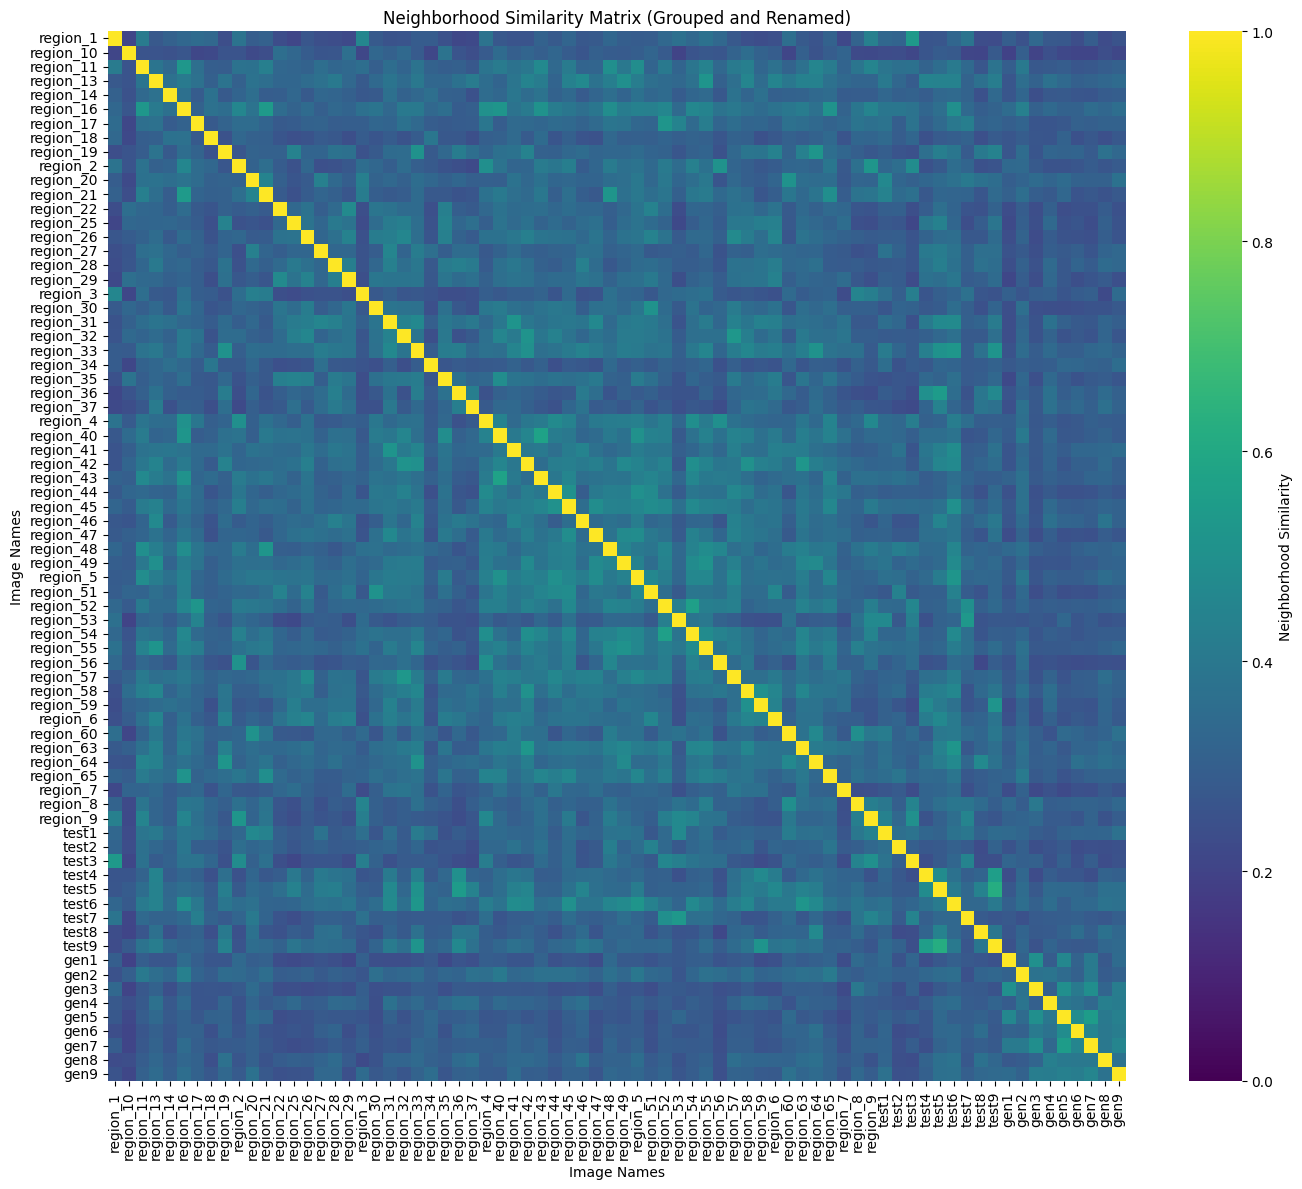

In [14]:
def process_filename(filename):
    """处理文件名：分组并重命名"""
    basename = os.path.splitext(filename)[0]  # 去掉扩展名

    if basename.startswith('region'):
        return ('region', basename)
    elif basename.startswith('t'):
        # 将t1-t9改为test1-test9
        num = basename[1:]  # 去掉't'后的数字
        return ('test', f'test{num}')
    elif basename.startswith('gen'):
        return ('gen', basename)
    else:
        return ('other', basename)
def load_images_from_folder(folder):
    """加载图像并进行文件名处理"""
    images = []
    filenames = []
    groups = []

    for filename in os.listdir(folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder, filename)
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # 转换为RGB
                    img = cv2.resize(img, (512,64))
                    images.append(img)

                    # 处理文件名
                    group, new_name = process_filename(filename)
                    filenames.append(new_name)
                    groups.append(group)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    return images, filenames, groups

import torch
# 加载数据集
train_folder = 'drive/MyDrive/202509Deprecated/trainset'
test_folder = 'drive/MyDrive/202509Deprecated/testset'

print("Loading training set...")
train_images, train_filenames, train_groups = load_images_from_folder(train_folder)
print(f"Loaded {len(train_images)} training images")

print("\nLoading test set...")
test_images, test_filenames, test_groups = load_images_from_folder(test_folder)
print(f"Loaded {len(test_images)} test images")

# 合并数据
all_images = train_images + test_images
all_filenames = train_filenames + test_filenames
all_groups = train_groups + test_groups

# 按照分组排序：region -> test -> gen
group_order = {'region': 0, 'test': 1, 'gen': 2}
sorted_indices = sorted(range(len(all_groups)),
                       key=lambda x: (group_order.get(all_groups[x], 3), all_filenames[x]))

all_images = [all_images[i] for i in sorted_indices]
all_filenames = [all_filenames[i] for i in sorted_indices]
all_groups = [all_groups[i] for i in sorted_indices]
# —— 将所有图先一次性转成 type tensor，避免重复映射 —— #
print("\nConverting RGB -> type maps...")
type_tensors = [
    torch.from_numpy(rgb_to_type_map(img)).unsqueeze(0)  # [1, H, W]
    for img in tqdm(all_images, desc="RGB->Type")
]

def compute_neighborhood_matrix(type_tensors, k=50, n_clusters=5):
    """
    使用你现成的 neighbor_kmeans_composition_matching_score 两两计算相似度
    相似度 = 1 / (1 + total_dist)，范围(0,1]，越大越相似
    """
    n = len(type_tensors)
    mat = np.ones((n, n), dtype=np.float32)

    print("\nComputing pairwise Neighborhood similarities...")
    for i in tqdm(range(n), desc="Row"):
        for j in range(i + 1, n):
            # 该函数需要 true_map + 3个gen_map；这里把 j 当作 gen，重复三次即可
            scores = neighbor_kmeans_composition_matching_score(
                true_map=type_tensors[i],
                gen_map1=type_tensors[j],
                gen_map2=type_tensors[j],
                gen_map3=type_tensors[j],
                k=k,                 # 你可按需改小提速
                n_clusters=10,
                visualize=False       # 关掉可视化
            )
            sim_ij = float(scores[0])  # 返回三个相同的分数，取第一个
            mat[i, j] = mat[j, i] = sim_ij
    return mat

print("\nCalculating Neighborhood matrix...")
nb_matrix = compute_neighborhood_matrix(type_tensors, k=20, n_clusters=5)

# —— 画热图（紫→黄配色 plasma） —— #
plt.figure(figsize=(14, 12))
sns.heatmap(
    nb_matrix,
    cmap='viridis',                     # 从紫到黄
    xticklabels=all_filenames,
    yticklabels=all_filenames,
    cbar_kws={'label': 'Neighborhood Similarity'},
    vmin=0, vmax=1
)
plt.title('Neighborhood Similarity Matrix (Grouped and Renamed)')
plt.xlabel('Image Names')
plt.ylabel('Image Names')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("grouped_neighborhood_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
plt.figure(figsize=(14, 12))
sns.heatmap(ssim_matrix,
            cmap='viridis',
            xticklabels=all_filenames,
            yticklabels=all_filenames,
            cbar_kws={'label': 'SSIM Score'},
            vmin=0, vmax=1)

plt.title('SSIM Similarity Matrix (Grouped and Renamed)')
plt.xlabel('Image Names')
plt.ylabel('Image Names')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("grouped_ssim_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

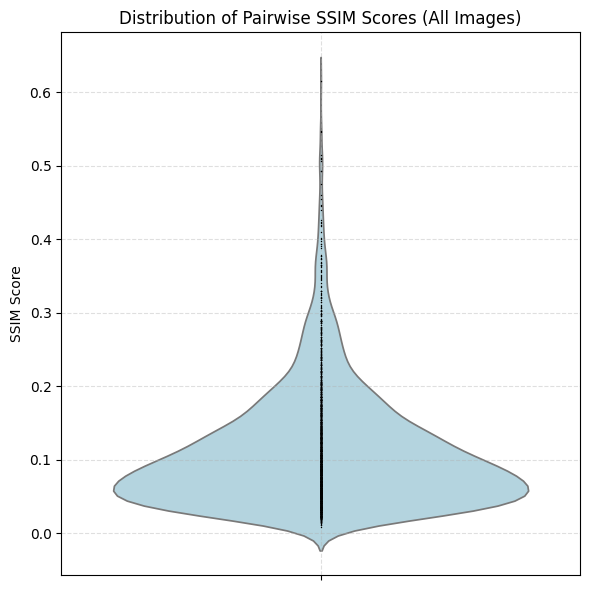

In [ ]:
import pandas as pd

# 1. 处理 SSIM 值为一维向量（排除自身对比 i == j）
def extract_ssim_pairs(matrix):
    n = matrix.shape[0]
    values = []
    for i in range(n):
        for j in range(i+1, n):
            values.append(matrix[i, j])
    return values

ssim_values_all = extract_ssim_pairs(ssim_matrix)

# 2. 用 pandas dataframe 包装
df_ssim = pd.DataFrame({'SSIM': ssim_values_all})

# 3. 画箱线图
plt.figure(figsize=(6, 6))
sns.violinplot(data=df_ssim, y='SSIM', inner=None, color='lightblue')
sns.stripplot(data=df_ssim, y='SSIM', color='black', size=1, jitter=0, alpha=1)
plt.title('Distribution of Pairwise SSIM Scores (All Images)')
plt.ylabel('SSIM Score')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("ssim_boxplot.png")
plt.show()


In [ ]:
import numpy as np
import torch
from scipy.stats import chi2_contingency
from sklearn.utils import resample

def cell_type_significance_test(type1, type2, n_permutations=1000, method='chi2'):
    """
    计算两幅图像细胞类型分布的全局差异显著性（忽略背景0）

    参数:
        type1 (torch.Tensor): 图像1的细胞类型标签 (512, 128), 0表示背景，1-25表示细胞类型
        type2 (torch.Tensor): 图像2的细胞类型标签 (512, 128)
        n_permutations (int): 置换检验的迭代次数
        method (str): 'chi2'或'permutation'

    返回:
        p_value (float): 显著性p值
        effect_size (float): 效应量
    """
    # 转换为numpy并展平，同时过滤背景值0
    type1_filtered = type1.cpu().numpy().flatten()
    type1_filtered = type1_filtered[type1_filtered > 0]  # 只保留1-25

    type2_filtered = type2.cpu().numpy().flatten()
    type2_filtered = type2_filtered[type2_filtered > 0]  # 只保留1-25

    # 统计细胞类型频数（1-25）
    bins = np.arange(1, 27)  # 1-25共25个边界
    hist1, _ = np.histogram(type1_filtered, bins=bins)
    hist2, _ = np.histogram(type2_filtered, bins=bins)

    # 合并为列联表（2组 x 25细胞类型）
    contingency_table = np.vstack([hist1, hist2])

    if method == 'chi2':
        try:
            chi2, p_value, _, _ = chi2_contingency(contingency_table)
            effect_size = chi2
        except ValueError:
            print("卡方检验失败（存在零频数），自动切换为置换检验")
            method = 'permutation'

    if method == 'permutation':
        observed_diff = np.abs(hist1 - hist2).sum()
        pooled = np.concatenate([type1_filtered, type2_filtered])
        n = len(type1_filtered)

        perm_diffs = []
        for _ in range(n_permutations):
            perm_labels = np.random.permutation(pooled)
            perm_hist1, _ = np.histogram(perm_labels[:n], bins=bins)
            perm_hist2, _ = np.histogram(perm_labels[n:], bins=bins)
            perm_diff = np.abs(perm_hist1 - perm_hist2).sum()
            perm_diffs.append(perm_diff)

        p_value = (np.sum(perm_diffs >= observed_diff) + 1) / (n_permutations + 1)
        effect_size = observed_diff

    return p_value#, effect_size

In [ ]:
import numpy as np
from scipy.spatial.distance import jensenshannon
from scipy.ndimage import generic_filter

def compute_neighbor_distribution(type_map, num_types=25, window_size=3):
    """
    对于每种 cell type，计算其周围邻居的 cell type 分布。
    返回邻接矩阵 A: [num_types, num_types]，A[i,j] 表示第 i 类细胞邻居中第 j 类的频数。
    """
    type_map = type_map.squeeze().cpu().numpy()
    H, W = type_map.shape
    A = np.zeros((num_types, num_types), dtype=np.float32)

    pad = window_size // 2
    padded = np.pad(type_map, pad_width=pad, mode='constant', constant_values=0)

    for i in range(pad, H + pad):
        for j in range(pad, W + pad):
            center = padded[i, j]
            if center == 0:  # 忽略背景
                continue
            neighbors = padded[i-pad:i+pad+1, j-pad:j+pad+1].flatten()
            neighbors = neighbors[neighbors > 0]  # 去掉背景
            for n in neighbors:
                if n != center:  # 不算自己
                    A[int(center)-1, int(n)-1] += 1

    return A

def normalize_rows(matrix):
    """对每行进行归一化"""
    row_sums = matrix.sum(axis=1, keepdims=True) + 1e-8
    return matrix / row_sums

def neighborhood_js_divergence(type_map1, type_map2):
    A1 = compute_neighbor_distribution(type_map1)
    A2 = compute_neighbor_distribution(type_map2)
    A1 = normalize_rows(A1)
    A2 = normalize_rows(A2)

    total_js = 0
    valid_rows = 0

    for i in range(len(A1)):
        row1 = A1[i]
        row2 = A2[i]

        # 跳过任何一边为空的行
        if np.all(row1 == 0) and np.all(row2 == 0):
            continue

        # 避免 log(0)，加一个极小值
        row1 = row1 + 1e-8
        row2 = row2 + 1e-8

        # 再次归一化
        row1 = row1 / row1.sum()
        row2 = row2 / row2.sum()

        js = jensenshannon(row1, row2)
        if np.isnan(js):
            continue  # 跳过 NaN
        total_js += js
        valid_rows += 1

    return total_js / valid_rows if valid_rows > 0 else 0



Loading training set...
Loaded 56 training images

Loading test set...
Loaded 18 test images

Calculating SSIM matrix...


Computing SSIM: 100%|██████████| 74/74 [10:16<00:00,  8.32s/it]


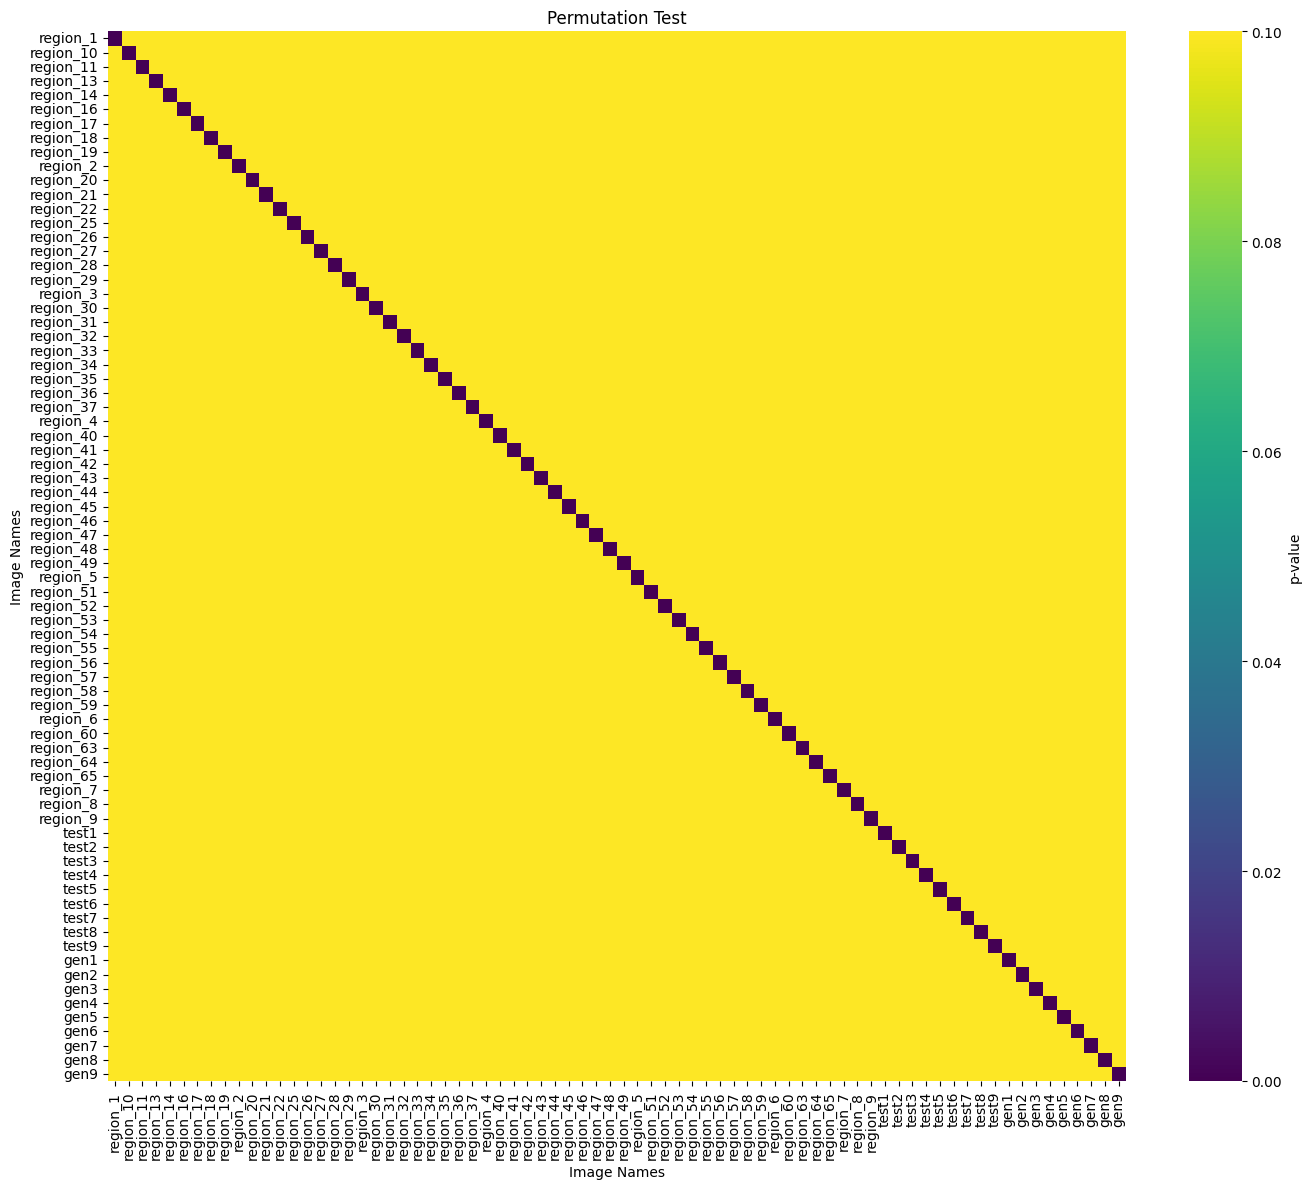

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
import os
import cv2

def process_filename(filename):
    """处理文件名：分组并重命名"""
    basename = os.path.splitext(filename)[0]  # 去掉扩展名

    if basename.startswith('region'):
        return ('region', basename)
    elif basename.startswith('t'):
        # 将t1-t9改为test1-test9
        num = basename[1:]  # 去掉't'后的数字
        return ('test', f'test{num}')
    elif basename.startswith('gen'):
        return ('gen', basename)
    else:
        return ('other', basename)

def load_images_from_folder(folder):
    """加载图像并进行文件名处理"""
    images = []
    filenames = []
    groups = []

    for filename in os.listdir(folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path).convert("RGB")
            img = img.resize((512,128))
            arr = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes()))
            rgb = arr.view(img.size[1], img.size[0], 3).permute(2, 0, 1).clone()  # [3, H, W], uint8

            mask = (rgb > 220).all(dim=0)
            rgb[:, mask] = 255
            rgb_float = rgb.float() / 255.0  # [3, H, W], float32
            images.append(rgb_float)

            # 处理文件名
            group, new_name = process_filename(filename)
            filenames.append(new_name)
            groups.append(group)


    return images, filenames, groups

# 加载数据集
train_folder = 'drive/MyDrive/trainset'
test_folder = 'drive/MyDrive/testset'

print("Loading training set...")
train_images, train_filenames, train_groups = load_images_from_folder(train_folder)
print(f"Loaded {len(train_images)} training images")

print("\nLoading test set...")
test_images, test_filenames, test_groups = load_images_from_folder(test_folder)
print(f"Loaded {len(test_images)} test images")

# 合并数据
all_images = train_images + test_images
all_filenames = train_filenames + test_filenames
all_groups = train_groups + test_groups

# 按照分组排序：region -> test -> gen
group_order = {'region': 0, 'test': 1, 'gen': 2}
sorted_indices = sorted(range(len(all_groups)),
                       key=lambda x: (group_order.get(all_groups[x], 3), all_filenames[x]))

all_images = [all_images[i] for i in sorted_indices]
all_filenames = [all_filenames[i] for i in sorted_indices]
all_groups = [all_groups[i] for i in sorted_indices]

model = Autoencoder()
model.load_state_dict(torch.load("newae2.pth"))
mnodel = model.to("cuda")


# 计算SSIM矩阵
def compute_ssim_matrix(images):
    n = len(images)
    ssim_matrix = np.zeros((n, n))

    for i in tqdm(range(n), desc="Computing SSIM"):
        for j in range(i+1, n):
            img1 = images[i]
            img2 = images[j]
            type1 = infer_cell_map(img1, model)
            type2 = infer_cell_map(img2, model)
            channel_axis = -1 if img1.ndim == 3 else None
            type1 = type1.to("cuda")
            type2 = type2.to("cuda")
            #print(type1)
            score = neighborhood_js_divergence(type1, type2)
            #print(score)
            ssim_matrix[i, j] = score
            ssim_matrix[j, i] = score

    return ssim_matrix

print("\nCalculating SSIM matrix...")
ssim_matrix = compute_ssim_matrix(all_images)

# 可视化
plt.figure(figsize=(14, 12))
sns.heatmap(ssim_matrix,
            cmap='viridis',
            xticklabels=all_filenames,
            yticklabels=all_filenames,
            cbar_kws={'label': 'p-value'},
            vmin=0, vmax=0.1)

plt.title('Permutation Test')
plt.xlabel('Image Names')
plt.ylabel('Image Names')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("grouped_ssim_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import cv2

from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import jensenshannon

# -----------------------
# 你的文件读取与排序逻辑
# -----------------------
def process_filename(filename):
    basename = os.path.splitext(filename)[0]
    if basename.startswith('region'):
        return ('region', basename)
    elif basename.startswith('t'):
        num = basename[1:]
        return ('test', f'test{num}')
    elif basename.startswith('gen'):
        return ('gen', basename)
    else:
        return ('other', basename)

def load_images_from_folder(folder):
    images, filenames, groups = [], [], []
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder, filename)
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (512, 128))  # (W,H)=(512,128)
                    images.append(img)
                    group, new_name = process_filename(filename)
                    filenames.append(new_name)
                    groups.append(group)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    return images, filenames, groups

train_folder = 'drive/MyDrive/trainset'
test_folder  = 'drive/MyDrive/testset'

print("Loading training set...")
train_images, train_filenames, train_groups = load_images_from_folder(train_folder)
print(f"Loaded {len(train_images)} training images")

print("\nLoading test set...")
test_images, test_filenames, test_groups = load_images_from_folder(test_folder)
print(f"Loaded {len(test_images)} test images")

all_images    = train_images + test_images
all_filenames = train_filenames + test_filenames
all_groups    = train_groups + test_groups

group_order = {'region': 0, 'test': 1, 'gen': 2}
sorted_indices = sorted(
    range(len(all_groups)),
    key=lambda x: (group_order.get(all_groups[x], 3), all_filenames[x])
)

all_images    = [all_images[i] for i in sorted_indices]
all_filenames = [all_filenames[i] for i in sorted_indices]
all_groups    = [all_groups[i] for i in sorted_indices]

type_color_dict = {
    1:[134.9,124.1,8.7],   2:[62.3,216.0,132.0], 3:[130.9,46.4,182.5],
    4:[92.8,63.6,202.5],   5:[140.1,239.7,189.0],6:[200.0,183.1,168.9],
    7:[108.3,16.1,142.3],  8:[132.7,217.1,223.4],9:[170.6,96.0,98.0],
    10:[68.4,101.1,101.3], 11:[4.6,146.9,145.6], 12:[177.1,1.5,112.2],
    13:[202.6,136.4,12.3], 14:[95.1,244.3,209.6],15:[32.5,214.2,217.8],
    16:[176.2,78.6,193.2], 17:[185.9,206.0,77.8],18:[212.0,39.3,35.0],
    19:[117.1,190.4,53.4], 20:[101.2,145.2,246.9],21:[13.7,179.1,133.2],
    22:[247.4,125.5,111.5],23:[122.9,151.0,150.0],24:[118.0,45.6,47.7],
    25:[31.1,114.7,222.5]
}
centers = np.array([type_color_dict[i] for i in range(1, 26)], dtype=np.float32)  # (25,3)

def rgb_to_type_map(img_rgb, white_thresh=250):
    """
    将RGB图映射为cell type map：
      - 背景（白色）像素设为0
      - 其他像素按最近的颜色中心赋值为1~25
    img_rgb: (H,W,3) uint8/float
    """
    H, W, _ = img_rgb.shape
    img = img_rgb.astype(np.float32)

    # 背景判定（全通道 > white_thresh）
    bg_mask = (img[..., 0] > white_thresh) & (img[..., 1] > white_thresh) & (img[..., 2] > white_thresh)

    flat = img.reshape(-1, 3)  # (N,3)
    # 计算到25个中心的欧氏距离，取最近
    # 批量广播：(N,1,3)-(1,25,3)->(N,25,3)->(N,25)
    d = flat[:, None, :] - centers[None, :, :]
    dist = np.sqrt((d ** 2).sum(axis=2))  # (N,25)
    labels = dist.argmin(axis=1) + 1      # 1..25
    labels = labels.reshape(H, W)

    labels[bg_mask] = 0  # 背景清零
    return labels.astype(np.int16)

# -----------------------
# 两两 Cell Density 相似度
# -----------------------
def cell_density_similarity(mapA, mapB, k=20, bin_width=0.1, penalty_value=30.0, max_points_per_type=5000):
    """
    mapA/mapB: (H,W) int, 0=背景,1..25=cell type
    返回：平均相似度 ∈ [0,1]，越大越相似
    """
    def coords_feats(m):
        ys, xs = np.where(m > 0)
        feats = m[ys, xs]
        coords = np.stack([ys, xs], axis=1).astype(np.float32)
        return coords, feats

    coordsA, featsA = coords_feats(mapA)
    coordsB, featsB = coords_feats(mapB)

    num_types = 25
    sims = []

    for t in range(1, num_types + 1):
        ptsA = coordsA[featsA == t]
        ptsB = coordsB[featsB == t]

        # 采样防止超大数据导致很慢
        if len(ptsA) > max_points_per_type:
            idx = np.random.choice(len(ptsA), max_points_per_type, replace=False)
            ptsA = ptsA[idx]
        if len(ptsB) > max_points_per_type:
            idx = np.random.choice(len(ptsB), max_points_per_type, replace=False)
            ptsB = ptsB[idx]

        if len(ptsA) < k + 1 or len(ptsB) < k + 1:
            sims.append(1.0 / (1.0 + penalty_value))
            continue

        # k近邻平均距离分布
        nbrsA = NearestNeighbors(n_neighbors=k + 1).fit(ptsA)
        dA, _ = nbrsA.kneighbors(ptsA)
        meanA = dA[:, 1:].mean(axis=1)

        nbrsB = NearestNeighbors(n_neighbors=k + 1).fit(ptsB)
        dB, _ = nbrsB.kneighbors(ptsB)
        meanB = dB[:, 1:].mean(axis=1)

        combined = np.concatenate([meanA, meanB])
        min_v, max_v = combined.min(), combined.max()
        if max_v - min_v < 1e-8:
            sims.append(1.0)
            continue

        # 归一 & 直方图
        normA = (meanA - min_v) / (max_v - min_v)
        normB = (meanB - min_v) / (max_v - min_v)

        bins = np.arange(0, 1 + bin_width, bin_width)
        histA, _ = np.histogram(normA, bins=bins)
        histB, _ = np.histogram(normB, bins=bins)

        # 平滑
        eps = 1e-8
        p = histA.astype(np.float64) + eps
        q = histB.astype(np.float64) + eps
        p /= p.sum()
        q /= q.sum()

        # JS距离 ∈ [0,1]，相似度 = 1 - JS
        jsd = jensenshannon(p, q)
        sim = 1.0 - jsd
        sims.append(sim)

    return float(np.mean(sims)) if sims else 0.0

def compute_cell_density_matrix(images):
    """
    images: list of RGB ndarray
    return: (n,n) 相似度矩阵
    """
    print("\nMapping RGB -> cell type maps...")
    type_maps = [rgb_to_type_map(img) for img in tqdm(images, desc="RGB->Type")]

    n = len(type_maps)
    mat = np.ones((n, n), dtype=np.float32)

    print("\nComputing pairwise Cell Density similarities...")
    for i in tqdm(range(n), desc="Row"):
        for j in range(i + 1, n):
            score = cell_density_similarity(type_maps[i], type_maps[j], k=20, bin_width=0.1, penalty_value=30.0)
            mat[i, j] = mat[j, i] = score
    return mat

print("\nCalculating Cell Density matrix...")
cd_matrix = compute_cell_density_matrix(all_images)

# -----------------------
# 可视化热图
# -----------------------
plt.figure(figsize=(14, 12))
sns.heatmap(cd_matrix,
            cmap='viridis',
            xticklabels=all_filenames,
            yticklabels=all_filenames,
            cbar_kws={'label': 'Cell Density Similarity'},
            vmin=0, vmax=1)
plt.title('Cell Density Similarity Matrix (Grouped and Renamed)')
plt.xlabel('Image Names')
plt.ylabel('Image Names')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("grouped_cell_density_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


Loading training set...
Loaded 56 training images

Loading test set...


KeyboardInterrupt: 

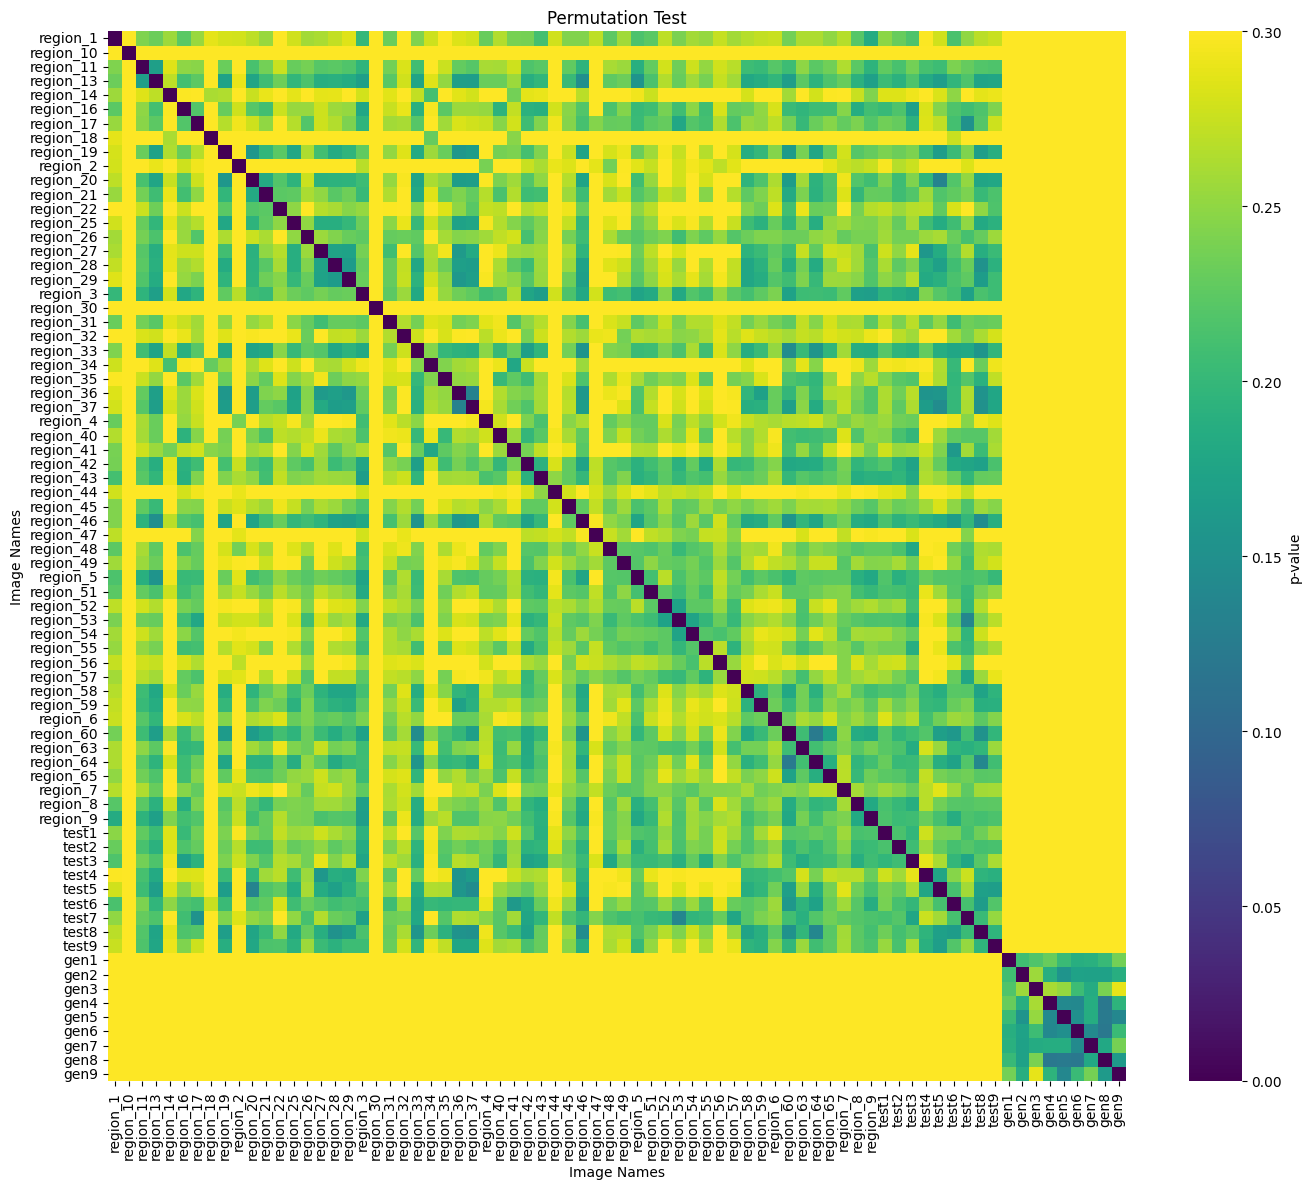

In [ ]:
plt.figure(figsize=(14, 12))
sns.heatmap(ssim_matrix,
            cmap='viridis',
            xticklabels=all_filenames,
            yticklabels=all_filenames,
            cbar_kws={'label': 'p-value'},
            vmin=0, vmax=0.3)

plt.title('Permutation Test')
plt.xlabel('Image Names')
plt.ylabel('Image Names')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("grouped_ssim_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(sum(sum(ssim_matrix > 0.2)))

4798


In [ ]:
pip install torch-fidelity


In [ ]:
pip install piqa

In [ ]:
from piqa import GMSD
gmsd_fn = GMSD().cuda().to("cuda")

In [ ]:
import lpips
import torch

lpips_fn = lpips.LPIPS(net='vgg').cuda()

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.11/dist-packages/lpips/weights/v0.1/vgg.pth


Loading training set...
Loaded 56 training images

Loading test set...
Loaded 18 test images

Calculating SSIM matrix...


Computing LPIPS: 100%|██████████| 74/74 [00:14<00:00,  5.21it/s]


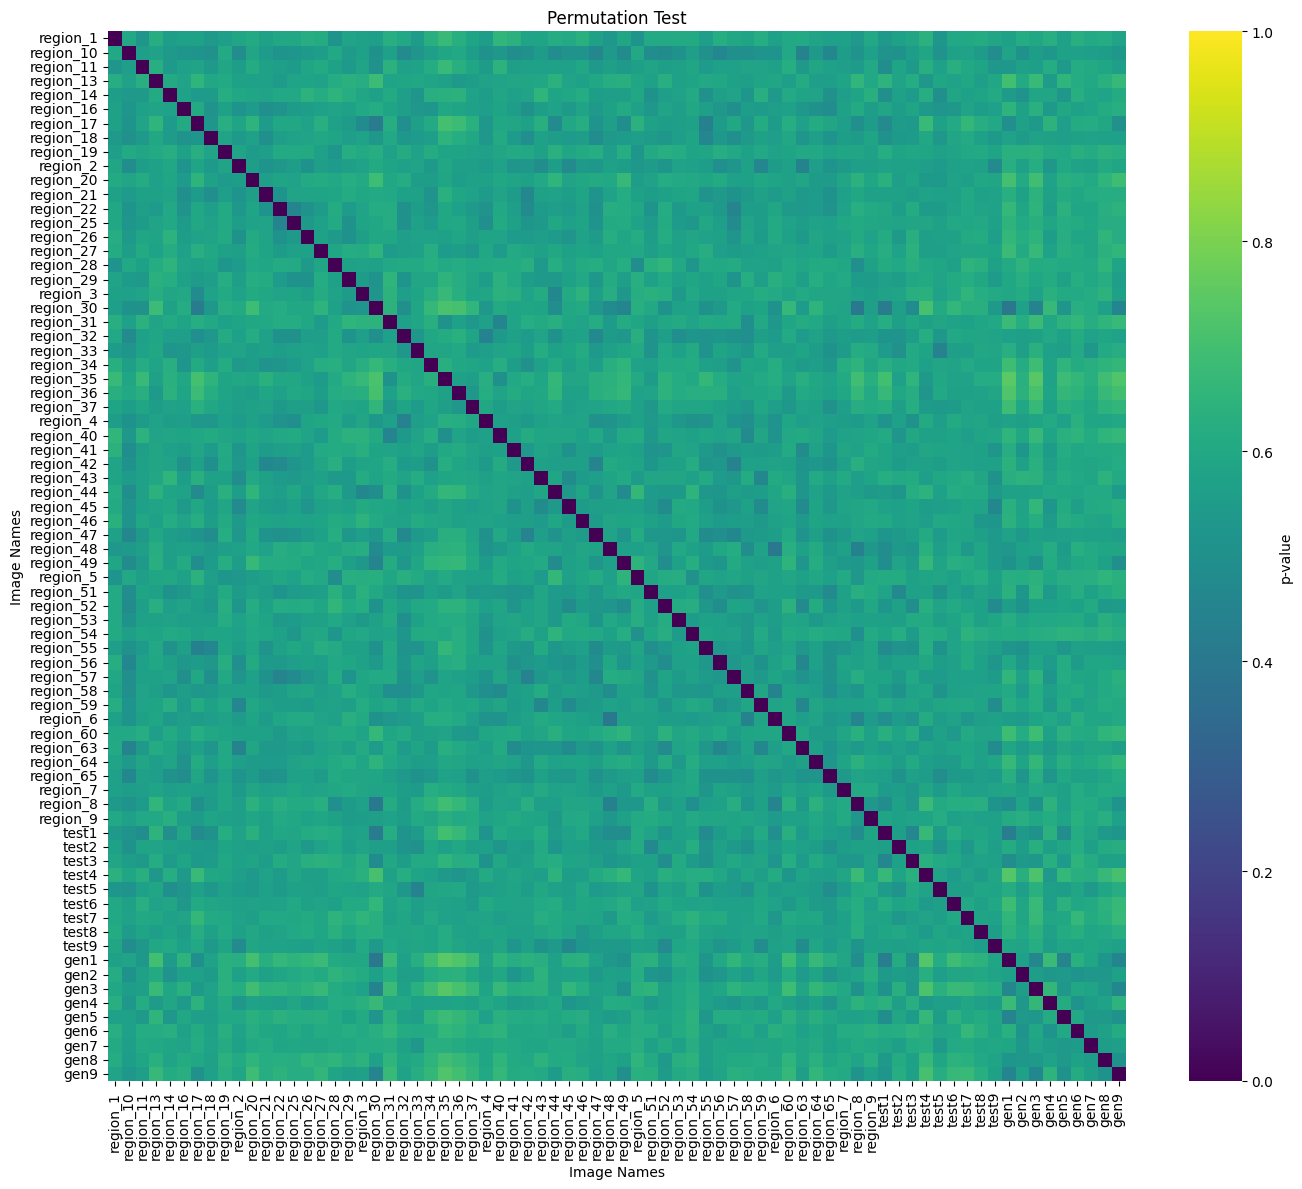

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
import os
import cv2

def process_filename(filename):
    """处理文件名：分组并重命名"""
    basename = os.path.splitext(filename)[0]  # 去掉扩展名

    if basename.startswith('region'):
        return ('region', basename)
    elif basename.startswith('t'):
        # 将t1-t9改为test1-test9
        num = basename[1:]  # 去掉't'后的数字
        return ('test', f'test{num}')
    elif basename.startswith('gen'):
        return ('gen', basename)
    else:
        return ('other', basename)

def load_images_from_folder(folder):
    """加载图像并进行文件名处理"""
    images = []
    filenames = []
    groups = []

    for filename in os.listdir(folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path).convert("RGB")
            img = img.resize((512,128))
            arr = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes()))
            rgb = arr.view(img.size[1], img.size[0], 3).permute(2, 0, 1).clone()  # [3, H, W], uint8
            mask = (rgb > 220).all(dim=0)
            rgb[:, mask] = 255
            rgb_float = rgb.float() / 255.0  # [3, H, W], float32
            images.append(rgb_float)

            # 处理文件名
            group, new_name = process_filename(filename)
            filenames.append(new_name)
            groups.append(group)


    return images, filenames, groups

# 加载数据集
train_folder = 'drive/MyDrive/trainset'
test_folder = 'drive/MyDrive/testset'

print("Loading training set...")
train_images, train_filenames, train_groups = load_images_from_folder(train_folder)
print(f"Loaded {len(train_images)} training images")

print("\nLoading test set...")
test_images, test_filenames, test_groups = load_images_from_folder(test_folder)
print(f"Loaded {len(test_images)} test images")

# 合并数据
all_images = train_images + test_images
all_filenames = train_filenames + test_filenames
all_groups = train_groups + test_groups

# 按照分组排序：region -> test -> gen
group_order = {'region': 0, 'test': 1, 'gen': 2}
sorted_indices = sorted(range(len(all_groups)),
                       key=lambda x: (group_order.get(all_groups[x], 3), all_filenames[x]))

all_images = [all_images[i] for i in sorted_indices]
all_filenames = [all_filenames[i] for i in sorted_indices]
all_groups = [all_groups[i] for i in sorted_indices]

model = Autoencoder()
model.load_state_dict(torch.load("newae2.pth"))
mnodel = model.to("cuda")


# 计算SSIM矩阵
# LPIPS 要求图像范围为 [-1, 1]，float32，形状为 [1, 3, H, W]
def preprocess_for_lpips(img):
    return (img * 2 - 1).unsqueeze(0).to("cuda")  # [1, 3, H, W], float, [-1, 1]

def compute_lpips_matrix(images):
    n = len(images)
    lpips_matrix = np.zeros((n, n))

    for i in tqdm(range(n), desc="Computing LPIPS"):
        img1 = preprocess_for_lpips(images[i])
        for j in range(i+1, n):
            img2 = preprocess_for_lpips(images[j])
            score = lpips_fn(img1, img2)
            value = score.item()
            lpips_matrix[i, j] = value
            lpips_matrix[j, i] = value

    return lpips_matrix


print("\nCalculating SSIM matrix...")
ssim_matrix = compute_lpips_matrix(all_images)

# 可视化
plt.figure(figsize=(14, 12))
sns.heatmap(ssim_matrix,
            cmap='viridis',
            xticklabels=all_filenames,
            yticklabels=all_filenames,
            cbar_kws={'label': 'p-value'},
            vmin=0, vmax=1)

plt.title('Permutation Test')
plt.xlabel('Image Names')
plt.ylabel('Image Names')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("grouped_ssim_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

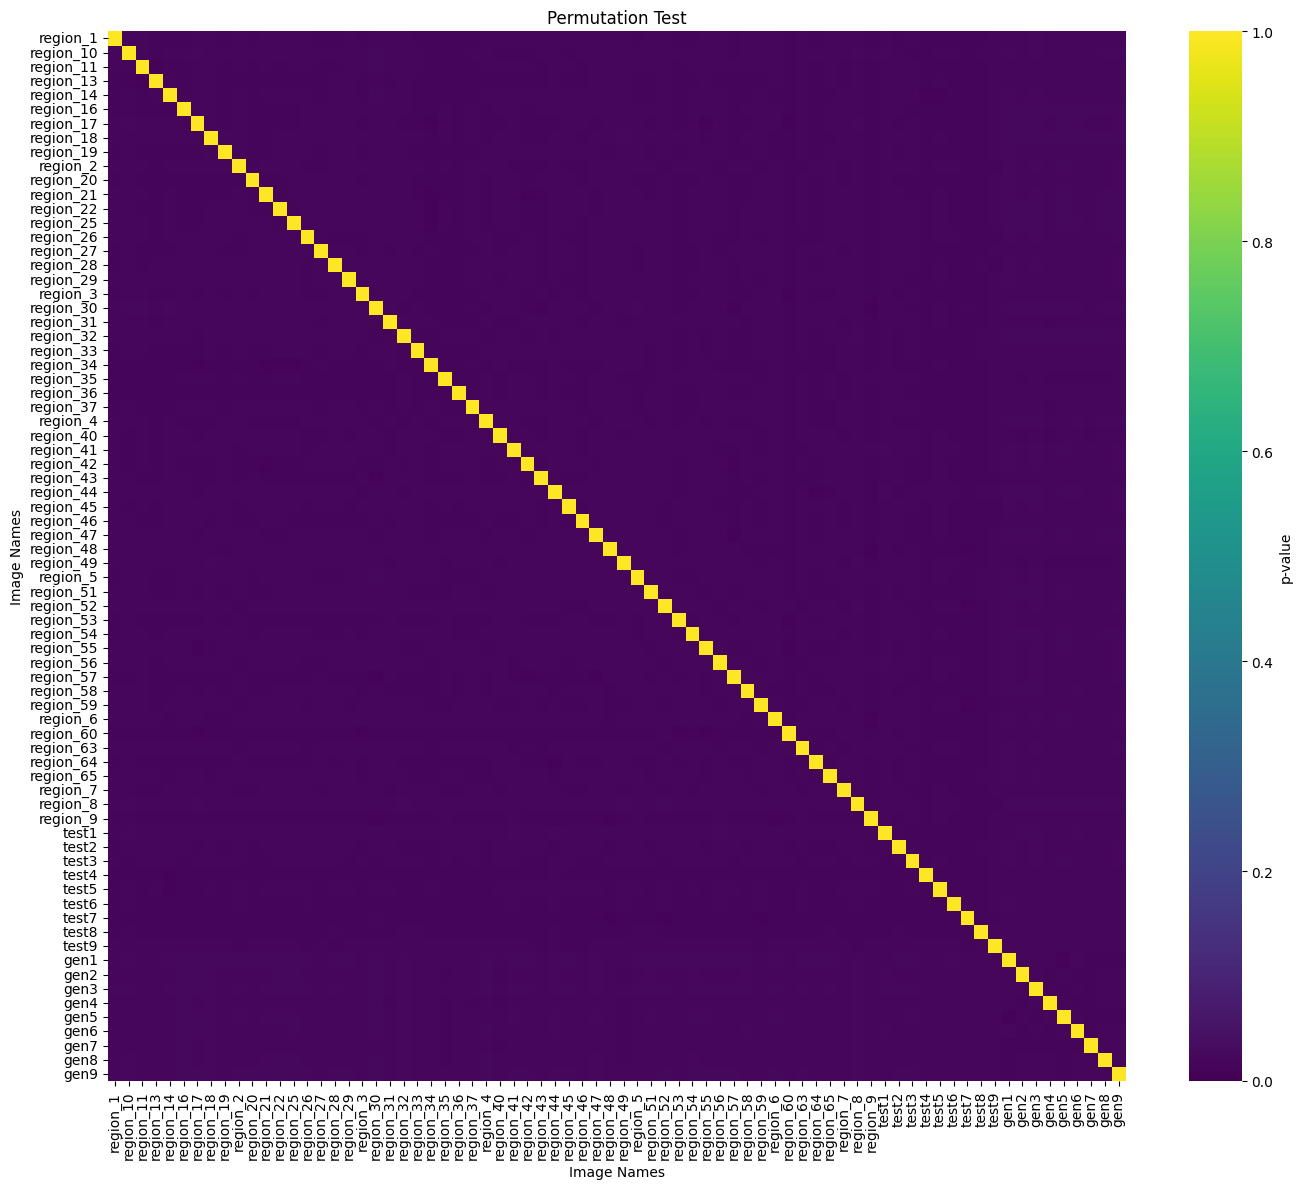

In [ ]:
# 可视化
plt.figure(figsize=(14, 12))
sns.heatmap(ssim_matrix,
            cmap='viridis',
            xticklabels=all_filenames,
            yticklabels=all_filenames,
            cbar_kws={'label': 'p-value'},
            vmin=0, vmax=1)

plt.title('Permutation Test')
plt.xlabel('Image Names')
plt.ylabel('Image Names')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("grouped_ssim_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
ssim_matrix

array([[0.        ,        nan, 0.24044679, ..., 0.48922348, 0.49564976,
        0.50994527],
       [       nan, 0.        ,        nan, ...,        nan,        nan,
               nan],
       [0.24044679,        nan, 0.        , ..., 0.50692022, 0.4878886 ,
        0.50587732],
       ...,
       [0.48922348,        nan, 0.50692022, ..., 0.        , 0.18109156,
        0.24430785],
       [0.49564976,        nan, 0.4878886 , ..., 0.18109156, 0.        ,
        0.16568905],
       [0.50994527,        nan, 0.50587732, ..., 0.24430785, 0.16568905,
        0.        ]])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

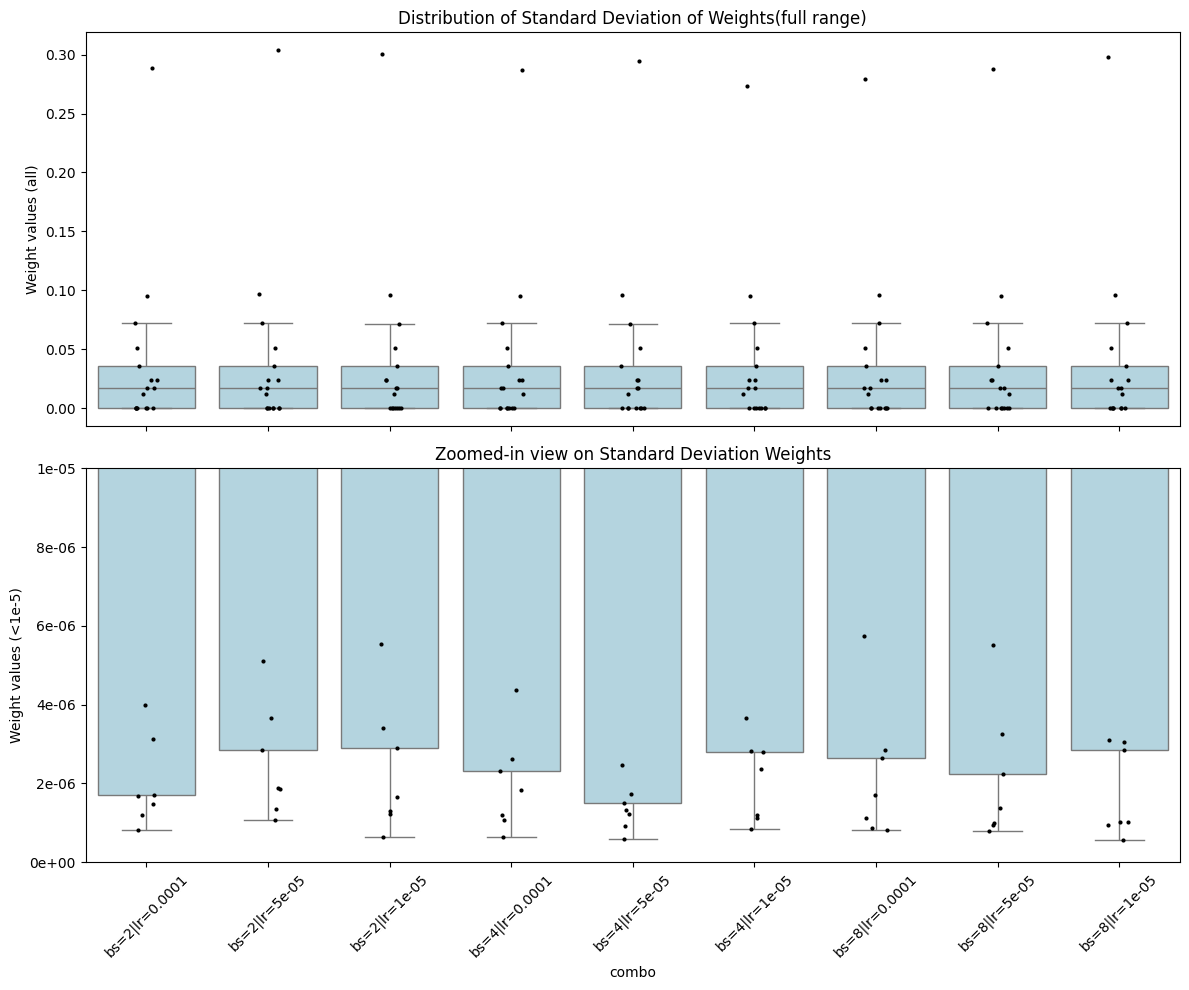

In [ ]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import FormatStrFormatter

# 读取 JSON
with open("drive/MyDrive/all_std_results.json", "r") as f:
    data = json.load(f)
with open("drive/MyDrive/disco_all_std_results.json", "r") as f:
    data1 = json.load(f)
with open("drive/MyDrive/4_disco_all_std_results.json", "r") as f:
    data2 = json.load(f)
with open("drive/MyDrive/8_disco_all_std_results.json", "r") as f:
    data3 = json.load(f)
with open("drive/MyDrive/81_disco_all_std_results.json", "r") as f:
    data4 = json.load(f)
# 转成 DataFrame
records = []
records1 = []
for combo, params in data.items():
    for k, v in params.items():
        if k.endswith("weight"):
            records.append({"combo": combo, "param": k, "value": v})
for combo, params in data1.items():
    for k, v in params.items():
        if k.endswith("weight"):
            records1.append({"combo": combo, "param": k, "value": v})
for combo, params in data2.items():
    for k, v in params.items():
        if k.endswith("weight"):
            records1.append({"combo": combo, "param": k, "value": v})
for combo, params in data3.items():
    for k, v in params.items():
        if k.endswith("weight"):
            records1.append({"combo": combo, "param": k, "value": v})
for combo, params in data4.items():
    for k, v in params.items():
        if k.endswith("weight"):
            records1.append({"combo": combo, "param": k, "value": v})

df = pd.DataFrame(records)
df1 = pd.DataFrame(records1)
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- 上图：全范围 ---
sns.boxplot(data=df, x="combo", y="value", showfliers=False, color="lightblue", ax=axes[0])
sns.stripplot(data=df, x="combo", y="value", color="black", size=3, jitter=True, ax=axes[0])
axes[0].set_ylabel("Weight values (all)")
axes[0].set_title("Distribution of Standard Deviation of Weights(full range)")

# --- 下图：放大到 [0, 1e-5] ---
sns.boxplot(data=df, x="combo", y="value", showfliers=False, color="lightblue", ax=axes[1])
sns.stripplot(data=df, x="combo", y="value", color="black", size=3, jitter=True, ax=axes[1])
axes[1].set_ylim(0, 1e-5)
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.0e'))  # ✅ 科学计数法

axes[1].set_ylabel("Weight values (<1e-5)")
axes[1].set_title("Zoomed-in view on Standard Deviation Weights")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipython-input-3275544863.py:20: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipython-input-3275544863.py:41: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipython-input-3275544863.py:61: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


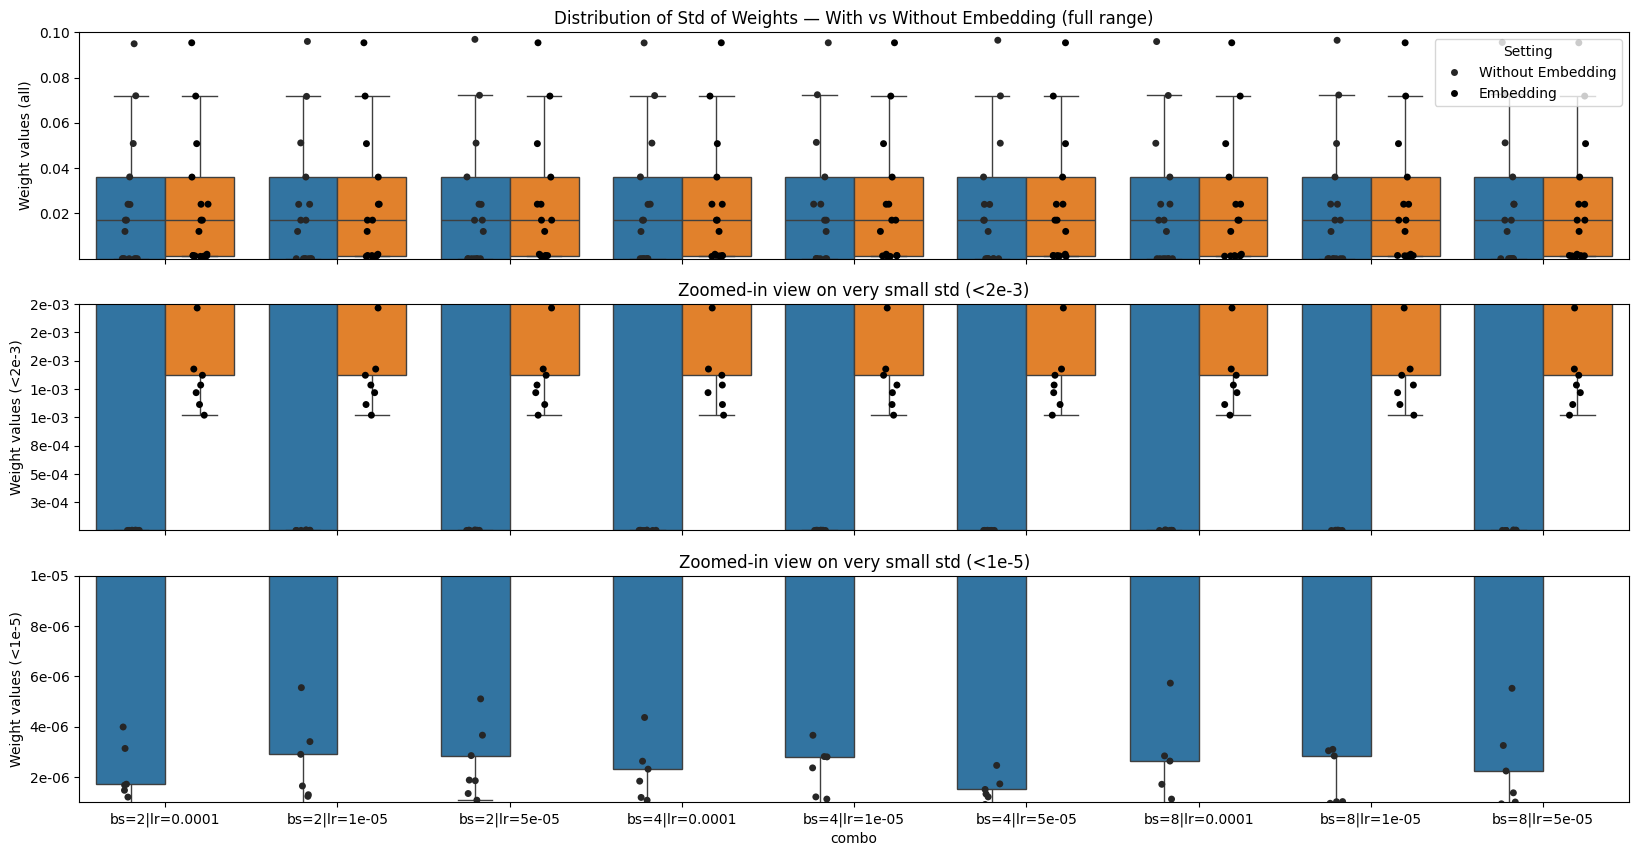

In [ ]:
# 为两个 df 加分组标记
df['group']  = 'Without Embedding'
df1['group'] = 'Embedding'

# 合并
df_all = pd.concat([df, df1], ignore_index=True)

# 统一 x 轴顺序（按组合名排序，或按出现顺序也可）
order = sorted(df_all['combo'].unique())
hue_order = ['Without Embedding', 'Embedding']

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

# --- 上图：全范围 ---
sns.boxplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    showfliers=False, ax=axes[0]
)
sns.stripplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    dodge=True, color="black",
    size=5, jitter=True, alpha=1, marker='o',
    ax=axes[0], linewidth=0
)
axes[0].set_ylim(1e-7, 1e-1)
axes[0].set_ylabel("Weight values (all)")
axes[0].set_title("Distribution of Std of Weights — With vs Without Embedding (full range)")
# 图例只保留一份
handles, labels = axes[0].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
axes[0].legend(uniq.values(), uniq.keys(), title="Setting", loc="best")

# --- 下图：放大到 [0, 1e-5] ---
sns.boxplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    showfliers=False, ax=axes[1]
)
sns.stripplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    dodge=True, color="black",
    size=5, jitter=True, alpha=1, marker='o',
    ax=axes[1], linewidth=0
)
axes[1].set_ylim(1e-6, 2e-3)
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.0e'))
axes[1].set_ylabel("Weight values (<2e-3)")
axes[1].set_title("Zoomed-in view on very small std (<2e-3)")

# 下图不需要图例
axes[1].legend().remove()

sns.boxplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    showfliers=False, ax=axes[2]
)
sns.stripplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    dodge=True, color="black",
    size=5, jitter=True, alpha=1, marker='o',
    ax=axes[2], linewidth=0
)
axes[2].set_ylim(1e-6, 1e-5)
axes[2].yaxis.set_major_formatter(FormatStrFormatter('%.0e'))
axes[2].set_ylabel("Weight values (<1e-5)")
axes[2].set_title("Zoomed-in view on very small std (<1e-5)")

# 下图不需要图例
axes[2].legend().remove()



/tmp/ipython-input-2562676521.py:19: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipython-input-2562676521.py:51: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipython-input-2562676521.py:70: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


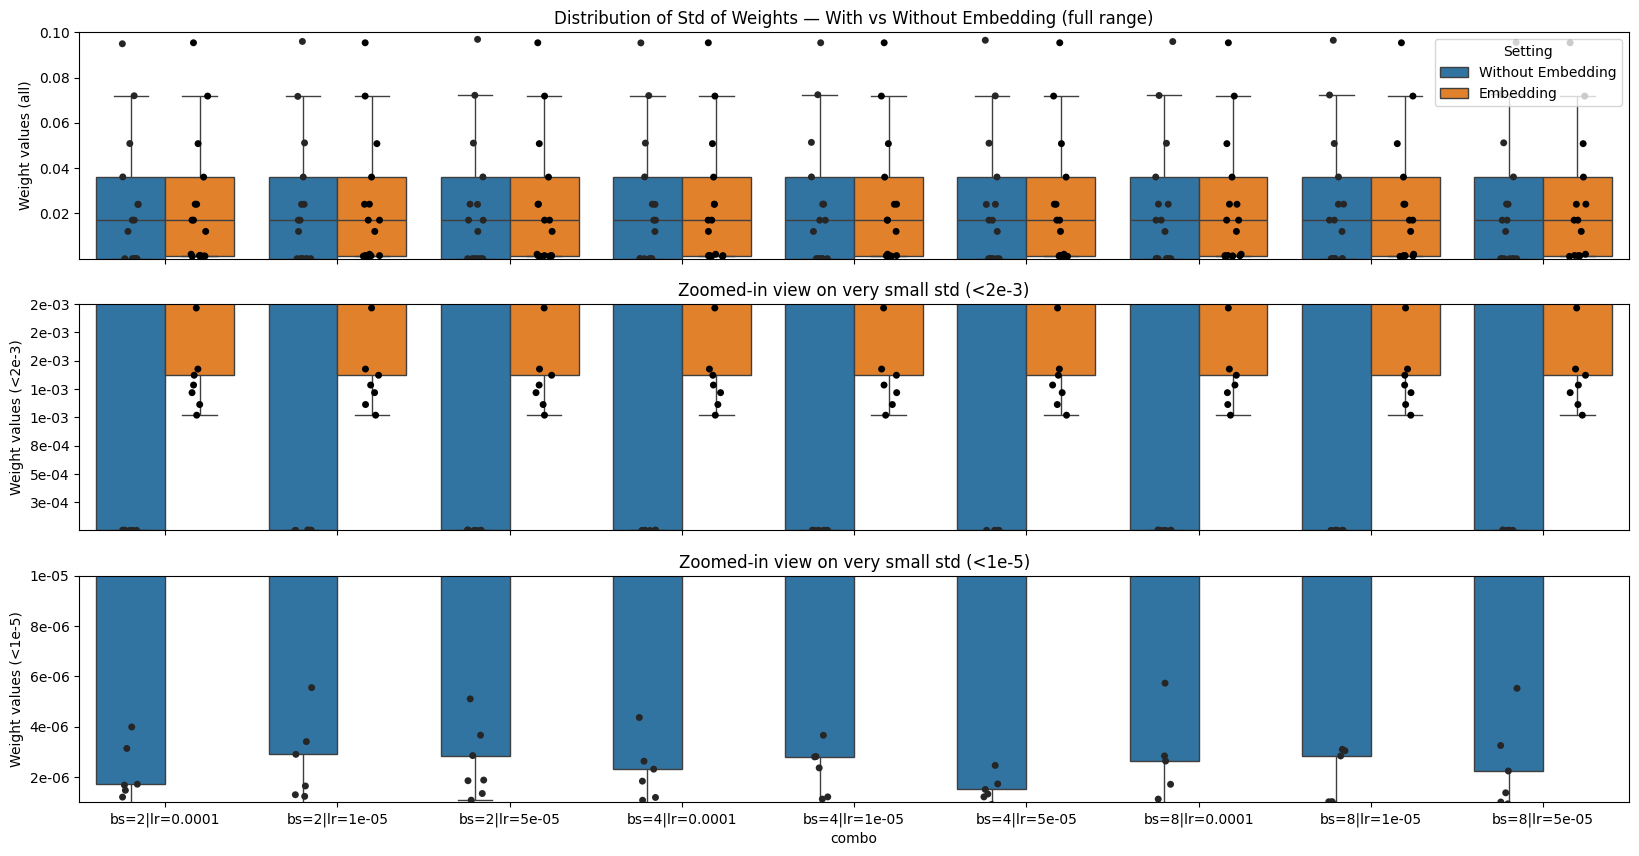

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# 调色板：蓝色=Without Embedding，橙色=Embedding
palette = {
    'Without Embedding': '#1f77b4',
    'Embedding': '#ff7f0e'
}

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

# --- 上图：全范围 ---
bp = sns.boxplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    showfliers=False, ax=axes[0], palette=palette
)
sns.stripplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    dodge=True, color="black",
    size=5, jitter=True, alpha=1, marker='o',
    ax=axes[0], linewidth=0
)
axes[0].set_ylim(1e-7, 1e-1)
axes[0].set_ylabel("Weight values (all)")
axes[0].set_title("Distribution of Std of Weights — With vs Without Embedding (full range)")

# ✅ 取出 box 的 Patch 来做图例（长方形）
handles, labels = axes[0].get_legend_handles_labels()
new_handles = []
for lh in handles:
    if isinstance(lh, plt.Line2D):  # stripplot 生成的点图例
        continue
    new_handles.append(lh)  # 只保留 boxplot 的矩形 Patch

axes[0].legend(
    new_handles,
    hue_order,
    title="Setting",
    loc="best"
)

# --- 中图 ---
sns.boxplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    showfliers=False, ax=axes[1], palette=palette
)
sns.stripplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    dodge=True, color="black",
    size=5, jitter=True, alpha=1, marker='o',
    ax=axes[1], linewidth=0
)
axes[1].set_ylim(1e-6, 2e-3)
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.0e'))
axes[1].set_ylabel("Weight values (<2e-3)")
axes[1].set_title("Zoomed-in view on very small std (<2e-3)")
axes[1].legend().remove()

# --- 下图 ---
sns.boxplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    showfliers=False, ax=axes[2], palette=palette
)
sns.stripplot(
    data=df_all, x="combo", y="value",
    hue="group", order=order, hue_order=hue_order,
    dodge=True, color="black",
    size=5, jitter=True, alpha=1, marker='o',
    ax=axes[2], linewidth=0
)
axes[2].set_ylim(1e-6, 1e-5)
axes[2].yaxis.set_major_formatter(FormatStrFormatter('%.0e'))
axes[2].set_ylabel("Weight values (<1e-5)")
axes[2].set_title("Zoomed-in view on very small std (<1e-5)")
axes[2].legend().remove()
